# Objectif du notebook 

Date de création : 1102/2026

On traite ici le cas intermédiaire : la librairie est peuplée à l'aide de la source active et la source à localiser est une source passive (bruit de bateau). 

In [1]:
# %matplotlib notebook

import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import scipy.signal as sp 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from datetime import timedelta, datetime
from scipy.stats import linregress
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

rtf_mfp_img_folder = os.path.join(img_folder, "rtf_mfp", "library_active_event_passive")

In [3]:
sys.path.append(project_root)
from publication.publication_figure import (
    PubFigure,
    LargeFigure,
    color,
    set_subfigures_abc_labels,
)
from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp_utils import (
    get_dists_2_passive_event,
    get_dists_2,
    get_dists,
    derive_doppler_jules,
)
from real_data_analysis.fiberscope_groix.src.fiberscope_groix_manager import (
    ActiveFiberscopeManager,
    PassiveFiberscopeManager,
    BandFilter,
)

# Chargement des données 

In [4]:
# Load GPS dataset for station coordinates
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))
# Load AIS
ds_ais = xr.open_dataset(os.path.join(data_folder, "ais.nc"))


# Load arrivals dataset
fpath = os.path.join(
    data_folder,
    f"processed_arrivals.nc",
)
ds_arr = xr.open_dataset(fpath)
df_arr = ds_arr.to_dataframe()

# Construction de la librairie de répliques 

## Sélection des positions statiques de référence

In [5]:
n_highest = 8

# For comparison and simplicity we will use only emission with duration_s = 5s (short chirps)
df_arr_short = df_arr.loc[df_arr["duration_s"] == 5]

# df_arr_short = df_arr_short.loc[df_arr_short["deployed_length_m"] == '8']

df_arr_static = df_arr_short.loc[df_arr["src_pos_status"] == "fixed"]
src_pos_static = df_arr_static["src_pos_point"].unique()
for src_pos in src_pos_static:
    df_src_pos = df_arr_static.loc[df_arr["src_pos_point"] == src_pos]
    seq_src_pos = df_src_pos["sequence_id"].unique()
    print(f"Position {src_pos} -> sequence {seq_src_pos}")

    depth = []
    lvl = []
    max_psnr = []

    seq_mean_fscore = []
    # seq_mean_psnr = []
    for seq_id in seq_src_pos:
        df_seq_id = df_src_pos.loc[df_src_pos["sequence_id"] == seq_id]
        mean_f_score = (
            df_seq_id["f_score_obs1"].iloc[0]
            + df_seq_id["f_score_obs2"].iloc[0]
            + df_seq_id["f_score_obs3"].iloc[0]
        ) / 3
        seq_mean_fscore.append(mean_f_score)

        psnr = np.max(
            (df_seq_id["psnr_obs1"] + df_seq_id["psnr_obs2"] + df_seq_id["psnr_obs3"]) / 3
        )
        max_psnr.append(psnr)

        depth.append(df_seq_id["deployed_length_m"].iloc[0])
        lvl.append(df_seq_id["board_voltage_v"].iloc[0])

    seq_mean_fscore = np.array(seq_mean_fscore)
    depth = np.array(depth)
    lvl = np.array(lvl)

    idx_sorted_fscore = np.argsort(seq_mean_fscore)[::-1]
    seq_mean_fscore_sorted = seq_mean_fscore[idx_sorted_fscore]
    seq_src_pos_sorted = seq_src_pos[idx_sorted_fscore]
    depth = depth[idx_sorted_fscore]
    lvl = lvl[idx_sorted_fscore]

    # Sel the n_highest scores
    print(f"\tTop {n_highest} sequences with highest f-score")
    seq_fscore_selection = seq_mean_fscore_sorted[:n_highest]
    seq_selection = seq_src_pos_sorted[:n_highest]
    for i in range(seq_selection.size):
        print(
            f"\t\tSequence {seq_selection[i]} -> {seq_mean_fscore_sorted[i]} ({depth[i]}m, lvl={lvl[i]}, psnr={max_psnr[i]}) "
        )

    # df_arr_plot = df_arr.loc[df_arr["src_pos_point"] == "4"]

Position 1 -> sequence [12 13 14 15 16 24 25 26 27 28 29]
	Top 8 sequences with highest f-score
		Sequence 24 -> 0.7472044764119117 (5m, lvl=4.0, psnr=88.34554396573766) 
		Sequence 12 -> 0.7289492450517466 (2m, lvl=4.0, psnr=67.70796225848493) 
		Sequence 13 -> 0.7179557900659793 (2m, lvl=2.0, psnr=36.89219949776674) 
		Sequence 25 -> 0.7001631818092378 (5m, lvl=2.0, psnr=18.120941813290386) 
		Sequence 14 -> 0.6931016552858357 (2m, lvl=1.0, psnr=nan) 
		Sequence 26 -> 0.6799971744453309 (5m, lvl=1.0, psnr=108.17228150908511) 
		Sequence 15 -> 0.6603463487590043 (2m, lvl=0.5, psnr=45.71747374110263) 
		Sequence 27 -> 0.24045919816420294 (5m, lvl=0.5, psnr=18.29277480788976) 
Position 2 -> sequence [35 39 40 41 42 43 44 47 51]
	Top 8 sequences with highest f-score
		Sequence 51 -> 0.7668708549928365 (8m, lvl=4.0, psnr=117.06146256278312) 
		Sequence 35 -> 0.7526367762885862 (2m, lvl=4.0, psnr=95.3677406633393) 
		Sequence 39 -> 0.7480880771916217 (5m, lvl=4.0, psnr=48.205591834718945) 

In [6]:
# Positions statiques aux dessus de chacun des OBS
# selected_static_sequences_1S = 151, 155, 167  # 2m, 5m, 8m  (4V)
# selected_static_sequences_2S = 116, 117, 118  # 4V, 2V, 1V  (5m)
# selected_static_sequences_3S = 143, 127, 131  # 8m, 2m, 5m  (4V)

# selected_static_sequences = (
#     selected_static_sequences_1S
#     + selected_static_sequences_2S
#     + selected_static_sequences_3S
# )


selected_static_sequences = [
    151,
    116,
    143,
    # 51,
    # 55,
]


df_library = df_arr_static.loc[df_arr_static["sequence_id"].isin(selected_static_sequences)]

In [7]:
library_dict = {}
for seq_id in selected_static_sequences:
    src_pos = df_library.loc[df_library["sequence_id"] == seq_id].iloc[0].src_pos_point
    library_dict[seq_id] = src_pos

library_dict

{151: '1S', 116: '2S', 143: '3S'}

## Calcul des répliques (RTF)

In [8]:
bandfilter = BandFilter(
    order=4,
    lowcut=200,
    highcut=990,
)
# bandfilter = None

rtf_estimator = "cs-evd"

h_index_ref = 1  # -> OBS 3 has the higher snr
# root_rtf_data = os.path.join(data_folder, "rtf")
plot_feature = False
process_pulse_one_by_one = True
estimate_ir_duration = False

tau_ir_hat = 0.2  # estimated impulse response duration from sequence 144
tau_ir_hat *= 2  # To ensure we include the entire response 
# tau_rtf_analysis = 10 * tau_ir_hat  # To ensure we include the entire response
tau_rtf_analysis = 3

fs = 2000
# Number of samples corresponding to the assumed impulse response duration
n_rtf_analysis = int(tau_rtf_analysis * fs)
# Get closer power of 2
nperseg = 2 ** int(
    np.log2(n_rtf_analysis) + 1
)  # Number of sample per snapshot to use = closest power of two
alpha_overlap = 0.75
noverlap = int(nperseg * alpha_overlap)

print(f"tau = {tau_rtf_analysis}s")
print(f"nperseg = {nperseg} ({nperseg * 1/fs}s), noverlap = {noverlap}")

fsm = ActiveFiberscopeManager(
    root_processed_data=data_folder,
    h_index_ref=h_index_ref,
    plot_feature=plot_feature,
    bandfilter=bandfilter,
    tau_ir=tau_ir_hat,
    process_pulse_one_by_one=process_pulse_one_by_one,
    estimate_ir_duration=estimate_ir_duration,
    rtf_estimator=rtf_estimator,
    verbose=False,
)

fsm.nperseg = nperseg
fsm.noverlap = noverlap

fsm.process_analysis(
    df_arrivals=df_library,
    set_stft_props=False,
)

tau = 3s
nperseg = 8192 (4.096s), noverlap = 6144
Progress: ████████████████████████████████████████████████████████████████████████████████████████████████████ 100%

# Source event à localiser : Jules passant au dessus de l'OBS 3

In [9]:
# Define the period of interest
# 72025-10-15T10:16:40.000000000, 2025-10-15T11:23:10.000000000
# t_start = datetime(year=2025, month=10, day=15, hour=10, minute=00, second=00)
# t_end = datetime(year=2025, month=10, day=15, hour=10, minute=30, second=00)

# t_start = datetime(year=2025, month=10, day=15, hour=11, minute=10, second=00)
# t_end = datetime(year=2025, month=10, day=15, hour=11, minute=20, second=00)


t_start = datetime(year=2025, month=10, day=15, hour=10, minute=8, second=00)
t_end = datetime(year=2025, month=10, day=15, hour=11, minute=32, second=00)
print(t_start, t_end)

2025-10-15 10:08:00 2025-10-15 11:32:00


In [10]:
root_fig = os.path.join(rtf_mfp_img_folder, f"{datetime.strftime(t_start, fsm.datetime_fmt)}_to_{datetime.strftime(t_end, fsm.datetime_fmt)}")
if not os.path.exists(root_fig):
    os.makedirs(root_fig)

[228000210, 227814270, 226916000, 227315990, 228121530]


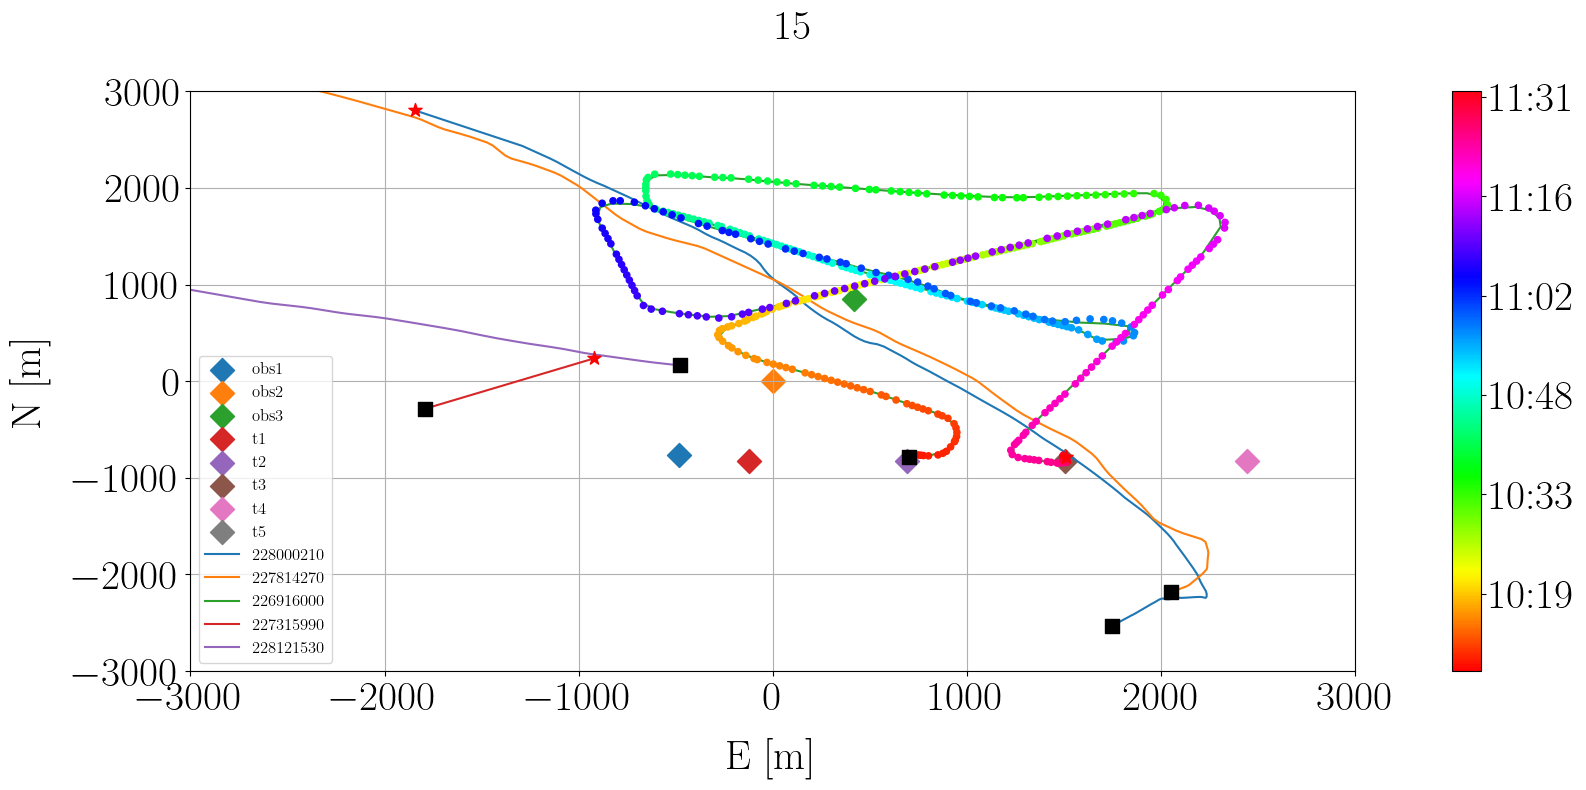

In [11]:
gps_day = ds_gps.sel(time=slice(t_start, t_end))
ais_day = ds_ais.sel(time=slice(t_start, t_end))


# Filter AIS data in area

e_min = -1000
e_max = +1000
n_min = -1000
n_max = +1000

mmsi_in_box = []
for mmsi in ds_ais.mmsi.values:
    ship = ais_day.sel(mmsi=mmsi)
    ship_in_e_range = np.logical_and(ship.e.values >= e_min, ship.e.values <= e_max)
    ship_in_n_range = np.logical_and(ship.n.values >= n_min, ship.n.values <= n_max)
    ship_in_box = np.logical_and(ship_in_e_range, ship_in_n_range)

    if np.any(ship_in_box):
        mmsi_in_box.append(mmsi)

print(mmsi_in_box)
ais_day = ais_day.sel(mmsi=mmsi_in_box)


# gps_day = gps_day.isel(time=slice(3700, 4100))
# print(f"{gps_day.time.min().values}, {gps_day.time.max().values}")
fig, ax = plt.subplots(1, 1, figsize=(16, 8), sharex=False, sharey=False)
fig.suptitle(f"{str(t_start.day)}")

keys = ["obs1", "obs2", "obs3", "t1", "t2", "t3", "t4", "t5"]
for k in keys:
    e = ds_gps.attrs[f"{k}_e_apriori"]
    n = ds_gps.attrs[f"{k}_n_apriori"]
    ax.scatter(
        e,
        n,
        marker="D",
        label=k,
        zorder=1,
        s=150,
    )

# # ENU
# im = ax.scatter(
#     gps_day.e,
#     gps_day.n,
#     marker="o",
#     c=np.arange(gps_day.e.size),
#     # c=gps_day.time.values,
#     s=6,
#     cmap="jet",
# )
# plt.colorbar(im)


times = mdates.date2num(gps_day.time)
im = ax.scatter(
    gps_day.e,
    gps_day.n,
    c=times,
    s=20,
    cmap="hsv",
    zorder=4,
)
cbar = plt.colorbar(im)
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

# Add ships in the area using AIS
for mmsi in ais_day.mmsi.values:
    ship = ais_day.sel(mmsi=mmsi)
    plt.plot(ship.e.values, ship.n.values, label=mmsi)
    plt.scatter(ship.e.values[0], ship.n.values[0], marker="s", s=100, color="k", zorder=5)
    plt.scatter(
        ship.e.values[-1], ship.n.values[-1], marker="*", s=100, color="r", zorder=5
    )


plt.xlim(-3000, 3000)
plt.ylim(-3000, 3000)

ax.legend(fontsize=12)
ax.grid()
ax.set_title("")
ax.set_xlabel("E [m]")
ax.set_ylabel("N [m]")

fpath = os.path.join(root_fig, "situation_ais_gps.png")
plt.savefig(fpath)

In [12]:
# Load wav data and plot the corresponding sequence
ds_wav = xr.open_dataset(os.path.join(data_folder, "channel_H_wav.nc"))

# Paramètre STFT
nperseg = 2**12
noverlap = 2**11

fig, axs = plt.subplots(3, 1, sharex=True, figsize=(16, 12))
axs = np.atleast_1d(axs)

for i, obs_id in enumerate([1, 2, 3]):

    datetime_fmt = ds_wav.attrs["datetime_format"]

    sig_varname = f"signal_obs{obs_id}"
    time_coordsname = f"time{obs_id}"
    signal = ds_wav[sig_varname]

    # Select a window of the signal
    fs = ds_wav.attrs[f"fs_obs{obs_id}"]

    # Start of recording
    t0 = ds_wav.attrs[f"start_datetime_obs{obs_id}"]
    t0 = datetime.strptime(t0, datetime_fmt)

    # Select window
    t_from_t0_start_s = (t_start - t0).total_seconds()
    n_start = int(t_from_t0_start_s * fs)
    t_from_t0_end_s = (t_end - t0).total_seconds()
    n_end = int(t_from_t0_end_s * fs)

    # Slice signal
    sig_win = signal.isel({time_coordsname: slice(n_start, n_end)})

    # Define datetime borders
    t0_slice = t0 + timedelta(seconds=n_start * 1 / fs)
    t1_slice = t0 + timedelta(seconds=n_end * 1 / fs)

    # Derive stft
    ff, tt, stft = sp.stft(
        sig_win.values,  # .values -> ici on charge les données en mémoire (un tout petit subset seulement)
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        scaling="psd",  # U^2 / Hz
    )
    sxx = 10 * np.log10(np.abs(stft))  # dB re 1uPa**2 / Hz ou dB re 1 (m/s)^2 / Hz
    # Associated datetime vector
    tt_datetime = pd.date_range(
        t0_slice,
        t0_slice + timedelta(seconds=tt[-1]),
        freq=f"{tt[1]-tt[0]}s",
        inclusive="both",
    )

    # Plot
    cmap = "magma"
    # vmin = np.percentile(sxx, 10)
    # vmax = np.percentile(sxx, 99)
    vmin = 25
    vmax = 45

    im = axs[i].pcolormesh(tt_datetime, ff, sxx, cmap=cmap, vmin=vmin, vmax=vmax)

    clabel = r"dB re 1$\mu$Pa$^2$ / Hz"
    divider = make_axes_locatable(axs[i])
    cax = divider.append_axes("right", size="2%", pad=0.10)
    fig.colorbar(im, cax=cax, orientation="vertical", label=clabel)

    # axs[ich].colorbar(im, label=clabel)

    axs[i].set_title(f"OBS{obs_id}")

formatter = mdates.DateFormatter("%H:%M:%S")
axs[-1].xaxis.set_major_formatter(formatter)
formatter = mdates.DateFormatter("%H:%M:%S")
axs[-1].xaxis.set_major_formatter(formatter)
locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
axs[-1].xaxis.set_major_locator(locator)
plt.setp(axs[-1].get_xticklabels(), rotation=15, ha="right")


# nticks = 10
# xmin, xmax = axs[-1].get_xlim()
# axs[-1].set_xticks(np.linspace(xmin, xmax, nticks))
# plt.setp(axs[-1].get_xticklabels(), rotation=25, ha="center")

fig.supylabel("Fréquence [Hz]")
fig.supxlabel("Temps UTC")
# fig.suptitle(f"OBS{obs_id}")

fpath = os.path.join(root_fig, "spectro_3obs.png")
plt.savefig(fpath, bbox_inches="tight")

In [ ]:
gps_day.time.attrs["long_name"] = "Temps UTC" 

spatial_dist = {}
spatial_dist_ais = {mmsi: {} for mmsi in ais_day.mmsi.values}

for seq_id in df_library["sequence_id"].unique():
    df_lib_seq_i = df_library.loc[df_library["sequence_id"] == seq_id]
    df_lib_seq_i = df_lib_seq_i.iloc[0]

    lib_pos_e = df_lib_seq_i["emission_interp_e_gps"]
    lib_pos_n = df_lib_seq_i["emission_interp_n_gps"]

    # Compute distance

    # GPS
    spatial_dist_i = np.sqrt(
        (lib_pos_e - gps_day.e) ** 2 + (lib_pos_n - gps_day.n) ** 2
    )

    spatial_dist_i.attrs["long_name"] = "Distance"
    spatial_dist[seq_id] = spatial_dist_i

    # AIS
    for mmsi in ais_day.mmsi.values:
        ship = ais_day.sel(mmsi=mmsi)

        dist_i_ais = np.sqrt(
            (lib_pos_e - ship.e) ** 2 + (lib_pos_n - ship.n) ** 2
        )
        dist_i_ais.attrs["long_name"] = "Distance"
        spatial_dist_ais[mmsi][seq_id] = dist_i_ais



In [ ]:
library_dict

In [ ]:
# plt.figure()
fig, axs = plt.subplots(len(spatial_dist.keys()), 1, sharex=True, figsize=(16, 12))
for i, seq_id in enumerate(spatial_dist.keys()):
    spatial_dist[seq_id].plot(label=f"GPS Jules", ax=axs[i])

    for mmsi in spatial_dist_ais.keys():
        spatial_dist_ais[mmsi][seq_id].plot(label=f"{mmsi}", ax=axs[i])

    axs[i].set_title(f"{library_dict[seq_id]} ({seq_id})")
    axs[i].set_xlabel("")
    axs[i].set_ylabel("")
    axs[i].legend(fontsize=12)

formatter = mdates.DateFormatter("%H:%M:%S")
axs[-1].xaxis.set_major_formatter(formatter)
locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
axs[-1].xaxis.set_major_locator(locator)
plt.setp(axs[-1].get_xticklabels(), rotation=15, ha="right")

# nticks = 10
# xmin, xmax = axs[-1].get_xlim()
# axs[-1].set_xticks(np.linspace(xmin, xmax, nticks))
# plt.setp(axs[-1].get_xticklabels(), rotation=25, ha="center")


fig.supxlabel("Temps UTC")
fig.supylabel("Distance [m]")
# plt.legend(fontsize=12)
# plt.ylim(0, 200)

In [ ]:
fs = 2000
tau_rtf_analysis = 3

# Number of samples corresponding to the assumed impulse response duration
n_rtf_analysis = int(tau_rtf_analysis * fs)
# Get closer power of 2
nperseg = 2 ** int(
    np.log2(n_rtf_analysis) + 1
)  # Number of sample per snapshot to use = closest power of two
alpha_overlap = 0.75
noverlap = int(nperseg * alpha_overlap)


# h_index_ref = 1  # -> OBS 3 has the higher snr
# root_rtf_data = os.path.join(data_folder, "rtf")
plot_feature = False
process_pulse_one_by_one = True
estimate_ir_duration = False

fsm = PassiveFiberscopeManager(
    root_processed_data=data_folder,
    h_index_ref=h_index_ref,
    plot_feature=plot_feature,
    bandfilter=None,
    tau_ir=tau_ir_hat,
    process_pulse_one_by_one=process_pulse_one_by_one,
    estimate_ir_duration=estimate_ir_duration,
    rtf_estimator=rtf_estimator,
    verbose=False,
    analysis_segment_duration = 10,
    analysis_segment_alpha_overlap = 0.5,
)

fsm.nperseg = nperseg
fsm.noverlap = noverlap

# Comment below if already computed
fsm.process_analysis(
    ds_wav,
    t_start,
    t_end,
    set_stft_props=False,
)

# Compute ambiguity distance 

In [ ]:
# Analyse rtf variations
fmin = 80      
fmax = 400

seq_library = df_library["sequence_id"].unique()
# seq_event = df_event["sequence_id"].unique()[0]

In [ ]:
spatial_dist_obs = {}
theta_dist_obs = {}
for seq_id_ref in seq_library:
    theta_dist, spatial_dist, xr_seq_ref, df_seq_ref, xr_passive = (
        get_dists_2_passive_event(
            fsm=fsm,
            df_arr=df_arr,
            seq_id_ref=seq_id_ref,
            ds_gps=gps_day,
            t_start=t_start,
            t_end=t_end,
            fmin=fmin,
            fmax=fmax,
            dist_type="hermitian_angle",
        )
    )

    idx_segment_min = np.argmin(theta_dist, axis=1)
    theta_dist = np.array(
        [theta_dist[i, idx_segment_min[i]] for i in range(theta_dist.shape[0])]
    )
    spatial_dist = np.array(
        [spatial_dist[i, idx_segment_min[i]] for i in range(spatial_dist.shape[0])]
    )
    # theta_dist, spatial_dist, xr_seq, df_seq = get_dists(
    #     fsm=fsm, df_arr=df_arr, seq_id_ref=seq_id_ref, seq_id=seq_event, fmin=fmin, fmax=fmax
    # )

    # Store in dict
    src_pos = library_dict[seq_id_ref]
    theta_dist_obs[src_pos] = {
        "id": seq_id_ref,
        "theta": theta_dist
    }
    spatial_dist_obs[src_pos] = {"id": seq_id_ref, "r": spatial_dist}


In [ ]:
for pos in theta_dist_obs.keys():
    idx_dist_min = np.argmin(spatial_dist_obs[pos]["r"])
    print(f"{pos} -> dist min for segment id {idx_dist_min} (d = {spatial_dist_obs[pos]['r'][idx_dist_min]})")

In [ ]:
# window_duration = 10
# window_overlap = 0.5
# segment_dt = []
# for segment_id in xr_passive.segment_id.values:    
#     t_end_segment = window_duration * (1 + (segment_id - 1) * (1 - window_overlap))
#     t_centre_segment_s = t_end_segment - 0.5 * window_duration
#     t_centre_segment = t_start + timedelta(seconds=t_centre_segment_s)
#     segment_dt.append(t_centre_segment)

# segment_dt = np.array(segment_dt)
segment_dt = xr_passive.time.values

In [ ]:
# mmsi_to_display = 228121530     # Passage au dessus de l'OBS 1
mmsi_to_display = 227814270
n_roll_avg = 1
lfig = LargeFigure(size=(16, 10), legend_fontsize=12)

fig, axs = plt.subplots(2, 1, sharex=True)
fig.suptitle(f"Event passive")

for pos in theta_dist_obs.keys():
    theta_roll_i = np.convolve(
        theta_dist_obs[pos]["theta"], np.ones(n_roll_avg) / n_roll_avg, mode="same"
    )

    axs[0].plot(segment_dt, theta_roll_i, label=f"{pos} ({theta_dist_obs[pos]['id']})")
    axs[0].legend(ncol=4, loc="upper right")

    axs[1].plot(
        segment_dt,
        spatial_dist_obs[pos]["r"],
        label=f"{pos} ({theta_dist_obs[pos]['id']})",
    )
    
    if mmsi_to_display in spatial_dist_ais.keys():
        seq_id = theta_dist_obs[pos]['id']
        spatial_dist_ais[mmsi_to_display][seq_id].plot(
            label=f"{pos} ({theta_dist_obs[pos]['id']}) vs {mmsi_to_display}", ax=axs[1]
        )

    axs[1].legend(ncol=4, loc="upper right")

axs[0].set_ylabel(r"$\theta$ [°]")
axs[1].set_ylabel("Distance [m]")
axs[1].set_xlabel("")

axs[1].set_title("")


# Subfigure annotations
# axs[0].text(
#     1.0,
#     1.02,
#     "(a)",
#     transform=axs[0].transAxes,
#     fontsize=16,
#     fontweight="bold",
#     ha="right",
#     va="bottom",
#     clip_on=False,
# )

# axs[1].text(
#     1.0,
#     1.02,
#     "(b)",
#     transform=axs[1].transAxes,
#     fontsize=16,
#     fontweight="bold",
#     ha="right",
#     va="bottom",
#     clip_on=False,
# )
# Subfigure annotations
axs[0].text(
    0.01,
    0.95,
    "(a)",
    transform=axs[0].transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
)

axs[1].text(
    0.01,
    0.95,
    "(b)",
    transform=axs[1].transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
)

formatter = mdates.DateFormatter("%H:%M:%S")
axs[-1].xaxis.set_major_formatter(formatter)
locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
axs[-1].xaxis.set_major_locator(locator)
plt.setp(axs[-1].get_xticklabels(), rotation=15, ha="right")

# nticks = 10
# xmin, xmax = axs[-1].get_xlim()
# axs[-1].set_xticks(np.linspace(xmin, xmax, nticks))
# plt.setp(axs[-1].get_xticklabels(), rotation=25, ha="center")


fig.supxlabel("Temps UTC")
fpath = os.path.join(root_fig, "theta_and_dist_vs_time.png")
plt.savefig(fpath)

In [ ]:
# mmsi_to_display = 228121530     # Passage au dessus de l'OBS 1
mmsi_to_display = 227814270
n_roll_avg = 1
lfig = LargeFigure(size=(16, 10), legend_fontsize=12)


for pos in theta_dist_obs.keys():

    fig, axs = plt.subplots(3, 1, sharex=True)
    fig.suptitle(f"Replicas {pos} ({theta_dist_obs[pos]['id']})")

    obs_id = pos[0]

    # Plot spectro
    datetime_fmt = ds_wav.attrs["datetime_format"]
    sig_varname = f"signal_obs{obs_id}"
    time_coordsname = f"time{obs_id}"
    signal = ds_wav[sig_varname]

    # Select a window of the signal
    fs = ds_wav.attrs[f"fs_obs{obs_id}"]

    # Start of recording
    t0 = ds_wav.attrs[f"start_datetime_obs{obs_id}"]
    t0 = datetime.strptime(t0, datetime_fmt)

    # Select window
    t_from_t0_start_s = (t_start - t0).total_seconds()
    n_start = int(t_from_t0_start_s * fs)
    t_from_t0_end_s = (t_end - t0).total_seconds()
    n_end = int(t_from_t0_end_s * fs)

    # Slice signal
    sig_win = signal.isel({time_coordsname: slice(n_start, n_end)})

    # Define datetime borders
    t0_slice = t0 + timedelta(seconds=n_start * 1 / fs)
    t1_slice = t0 + timedelta(seconds=n_end * 1 / fs)

    # Derive stft
    ff, tt, stft = sp.stft(
        sig_win.values,  # .values -> ici on charge les données en mémoire (un tout petit subset seulement)
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        scaling="psd",  # U^2 / Hz
    )
    sxx = 10 * np.log10(np.abs(stft))  # dB re 1uPa**2 / Hz ou dB re 1 (m/s)^2 / Hz
    # Associated datetime vector
    tt_datetime = pd.date_range(
        t0_slice,
        t0_slice + timedelta(seconds=tt[-1]),
        freq=f"{tt[1]-tt[0]}s",
        inclusive="both",
    )

    # Plot
    cmap = "magma"
    # vmin = np.percentile(sxx, 10)
    # vmax = np.percentile(sxx, 99)
    vmin = 25
    vmax = 45

    im = axs[0].pcolormesh(tt_datetime, ff, sxx, cmap=cmap, vmin=vmin, vmax=vmax)

    # clabel = r"dB re 1$\mu$Pa$^2$ / Hz"
    # divider = make_axes_locatable(axs[0])
    # cax = divider.append_axes("right", size="5%", pad=0.10)
    # fig.colorbar(im, cax=cax, orientation="vertical", label=clabel)

    # PLot theta
    theta_roll_i = np.convolve(
        theta_dist_obs[pos]["theta"], np.ones(n_roll_avg) / n_roll_avg, mode="same"
    )
    axs[1].plot(segment_dt, theta_roll_i, label=f"{pos} ({theta_dist_obs[pos]['id']})")
    axs[1].legend(ncol=4, loc="upper right")
    axs[1].set_ylim(0, 70)
    
    # Plot distance to ref
    axs[2].plot(
        segment_dt,
        spatial_dist_obs[pos]["r"],
        label=f"{pos} ({theta_dist_obs[pos]['id']})",
    )

    if mmsi_to_display in spatial_dist_ais.keys():
        seq_id = theta_dist_obs[pos]['id']
        spatial_dist_ais[mmsi_to_display][seq_id].plot(
            label=f"{pos} ({theta_dist_obs[pos]['id']}) vs {mmsi_to_display}", ax=axs[2]
        )

    axs[2].legend(ncol=4, loc="upper right")

    axs[1].set_ylabel(r"$\theta$ [°]")
    axs[2].set_ylabel("Distance [m]")
    axs[2].set_xlabel("")
    axs[2].set_title("")

    # Subfigure annotations
    axs[0].text(
        0.01,
        0.95,
        "(a)",
        transform=axs[0].transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
    )

    axs[1].text(
        0.01,
        0.95,
        "(b)",
        transform=axs[1].transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
    )

    axs[2].text(
        0.01,
        0.95,
        "(b)",
        transform=axs[2].transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
    )

    formatter = mdates.DateFormatter("%H:%M:%S")
    axs[-1].xaxis.set_major_formatter(formatter)
    locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
    axs[-1].xaxis.set_major_locator(locator)
    plt.setp(axs[-1].get_xticklabels(), rotation=15, ha="right")

    fig.supxlabel("Temps UTC")
    fpath = os.path.join(root_fig, f"theta_and_dist_vs_time_{pos}.png")
    plt.savefig(fpath)

# Analyse détaillée des résultats


## Focus sur l'OBS 3

L'objectif est de comprendre à quoi correspondent les minimums locaux de $\theta$ et de montrer que ces minimums correspondent aux cpas de différents navires. 

En particulier on cherchera à isoler les signaux correspondant au Jules et ceux des autres navires. 


In [ ]:
pos = "3S"
obs_id = pos[0]

root_obs_analysis = os.path.join(root_fig, pos)
root_obs_analysis_wav = os.path.join(
    data_folder,
    "result_analysis", 
    "library_active_event_passive",
    f"{datetime.strftime(t_start, fsm.datetime_fmt)}_to_{datetime.strftime(t_end, fsm.datetime_fmt)}",
    pos
)

if not os.path.exists(root_obs_analysis):
    os.makedirs(root_obs_analysis)
if not os.path.exists(root_obs_analysis_wav):
    os.makedirs(root_obs_analysis_wav)

### Étape 1 : définition des fenêtres d'analyse pour chaque minimums 

In [ ]:
n_roll_avg = 1

# Plot spectro
datetime_fmt = ds_wav.attrs["datetime_format"]
sig_varname = f"signal_obs{obs_id}"
time_coordsname = f"time{obs_id}"
signal = ds_wav[sig_varname]

# Select a window of the signal
fs = ds_wav.attrs[f"fs_obs{obs_id}"]

# Start of recording
t0 = ds_wav.attrs[f"start_datetime_obs{obs_id}"]
t0 = datetime.strptime(t0, datetime_fmt)

# Select window
t_from_t0_start_s = (t_start - t0).total_seconds()
n_start = int(t_from_t0_start_s * fs)
t_from_t0_end_s = (t_end - t0).total_seconds()
n_end = int(t_from_t0_end_s * fs)

# Slice signal
sig_win = signal.isel({time_coordsname: slice(n_start, n_end)})

# Define datetime borders
t0_slice = t0 + timedelta(seconds=n_start * 1 / fs)
t1_slice = t0 + timedelta(seconds=n_end * 1 / fs)

# Derive stft
ff, tt, stft = sp.stft(
    sig_win.values,  # .values -> ici on charge les données en mémoire (un tout petit subset seulement)
    fs=fs,
    window="hann",
    nperseg=nperseg,
    noverlap=noverlap,
    scaling="psd",  # U^2 / Hz
)
sxx = 10 * np.log10(np.abs(stft))  # dB re 1uPa**2 / Hz ou dB re 1 (m/s)^2 / Hz
# Associated datetime vector
tt_datetime = pd.date_range(
    t0_slice,
    t0_slice + timedelta(seconds=tt[-1]),
    freq=f"{tt[1]-tt[0]}s",
    inclusive="both",
)

In [ ]:
lfig = LargeFigure(size=(16, 10), legend_fontsize=12)

# Manually define analysis boxes
win_dur = timedelta(seconds=60*2)

box0 = {
    "center": datetime(2025, 10, 15, 10, 21, 38),
    "width": win_dur,
}
box1 = {
    "center": datetime(2025, 10, 15, 10, 24, 30),
    "width": win_dur,
}
box2 = {
    "center": datetime(2025, 10, 15, 10, 37, 35),
    "width": win_dur,
}
box3 = {
    "center": datetime(2025, 10, 15, 10, 49, 50),
    "width": win_dur,
}
box4 = {
    "center": datetime(2025, 10, 15, 10, 58, 35),
    "width": win_dur,
}
box5 = {
    "center": datetime(2025, 10, 15, 11, 1, 0),
    "width": win_dur,
}
box6 = {
    "center": datetime(2025, 10, 15, 11, 8, 10),
    "width": win_dur,
}
box7 = {
    "center": datetime(2025, 10, 15, 11, 11, 10),
    "width": win_dur,
}
box8 = {
    "center": datetime(2025, 10, 15, 11, 15, 30),
    "width": win_dur,
}
boxes = [box0, box1, box2, box3, box4, box5, box6, box7, box8]

fig, axs = plt.subplots(3, 1, sharex=True)
fig.suptitle(f"Replicas {pos} ({theta_dist_obs[pos]['id']})")

# Plot
cmap = "magma"
# vmin = np.percentile(sxx, 10)
# vmax = np.percentile(sxx, 99)
vmin = 25
vmax = 45

im = axs[0].pcolormesh(tt_datetime, ff, sxx, cmap=cmap, vmin=vmin, vmax=vmax)

# clabel = r"dB re 1$\mu$Pa$^2$ / Hz"
# divider = make_axes_locatable(axs[0])
# cax = divider.append_axes("right", size="5%", pad=0.10)
# fig.colorbar(im, cax=cax, orientation="vertical", label=clabel)

# PLot theta
theta_roll_i = np.convolve(
    theta_dist_obs[pos]["theta"], np.ones(n_roll_avg) / n_roll_avg, mode="same"
)
axs[1].plot(segment_dt, theta_roll_i, color="k", label=f"{pos} ({theta_dist_obs[pos]['id']})")
axs[1].legend(ncol=4, loc="upper right")
axs[1].set_ylim(0, 70)

# Plot distance to ref
axs[2].plot(
    segment_dt,
    spatial_dist_obs[pos]["r"],
    label=f"{pos} ({theta_dist_obs[pos]['id']})",
)

if mmsi_to_display in spatial_dist_ais.keys():
    seq_id = theta_dist_obs[pos]["id"]
    spatial_dist_ais[mmsi_to_display][seq_id].plot(
        label=f"{pos} ({theta_dist_obs[pos]['id']}) vs {mmsi_to_display}", ax=axs[2]
    )

axs[2].legend(ncol=4, loc="upper right")

axs[1].set_ylabel(r"$\theta$ [°]")
axs[2].set_ylabel("Distance [m]")
axs[2].set_xlabel("")
axs[2].set_title("")

# Add box visualisation
for i_box, box in enumerate(boxes):
    for ax in axs:
        ax.axvline(box["center"], color=color(i_box), label=f"box{i_box}")
        ax.axvline(box["center"] - 1 / 2 * box["width"], color=color(i_box), linestyle="--")
        ax.axvline(box["center"] + 1 / 2 * box["width"], color=color(i_box), linestyle="--")

axs[1].legend(ncol=2, loc="upper right")

# Subfigure annotations
axs[0].text(
    0.01,
    0.95,
    "(a)",
    transform=axs[0].transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
)

axs[1].text(
    0.01,
    0.95,
    "(b)",
    transform=axs[1].transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
)

axs[2].text(
    0.01,
    0.95,
    "(b)",
    transform=axs[2].transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
)

formatter = mdates.DateFormatter("%H:%M:%S")
axs[-1].xaxis.set_major_formatter(formatter)
locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
axs[-1].xaxis.set_major_locator(locator)
plt.setp(axs[-1].get_xticklabels(), rotation=15, ha="right")

fig.supxlabel("Temps UTC")

fpath = os.path.join(root_obs_analysis, f"box_definition.png")
plt.savefig(fpath)

#### Sauvegarde au format wav de chaque box

In [ ]:
from scipy.io import wavfile

# fs_, ex_data = wavfile.read(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\rhumrum\ABW_2013_31_05_12_33_00.wav")
# plt.figure()
# plt.plot(ex_data)
for i_box, box in enumerate(boxes):

    # Select current box window
    t_start_box = box["center"] - 1 / 2 * box["width"]
    t_end_box = box["center"] + 1 / 2 * box["width"]

    t_from_t0_start_s = (t_start_box - t0).total_seconds()
    n_start = int(t_from_t0_start_s * fs)
    t_from_t0_end_s = (t_end_box - t0).total_seconds()
    n_end = int(t_from_t0_end_s * fs)

    # Slice signal
    sig_box = signal.isel({time_coordsname: slice(n_start, n_end)})

    # Define datetime borders
    t0_slice = t0 + timedelta(seconds=n_start * 1 / fs)
    t1_slice = t0 + timedelta(seconds=n_end * 1 / fs)

    sig_box = sig_box / sig_box.max()

    # sig_box.plot()
    # Save corrected signal
    fpath = os.path.join(root_obs_analysis_wav, f"box{i_box}.wav")
    wavfile.write(
        fpath,
        fs,
        sig_box.values,
    )

### Étape 2 : étude de chaque box  

In [ ]:
lfig = LargeFigure(size=(18, 10), legend_fontsize=10)


nperseg=2**11
noverlap=int(nperseg*0.85)
offset = timedelta(seconds=120)

for i_box, box in enumerate(boxes):

    # Select current box window
    t_start_box = box["center"] - 1 / 2 * box["width"]
    t_end_box = box["center"] + 1 / 2 * box["width"]

    t_from_t0_start_s = (t_start_box - t0).total_seconds()
    n_start = int(t_from_t0_start_s * fs)
    t_from_t0_end_s = (t_end_box - t0).total_seconds()
    n_end = int(t_from_t0_end_s * fs)

    # Slice signal
    sig_box = signal.isel({time_coordsname: slice(n_start, n_end)})

    # Define datetime borders
    t0_slice = t0 + timedelta(seconds=n_start * 1 / fs)
    t1_slice = t0 + timedelta(seconds=n_end * 1 / fs)

    # Derive stft
    ff_box, tt_box, stft_box = sp.stft(
        sig_box.values,  # .values -> ici on charge les données en mémoire (un tout petit subset seulement)
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        scaling="psd",  # U^2 / Hz
    )
    sxx_box = 10 * np.log10(np.abs(stft_box))  # dB re 1uPa**2 / Hz ou dB re 1 (m/s)^2 / Hz
    # Associated datetime vector
    tt_datetime_box = pd.date_range(
        t0_slice,
        t0_slice + timedelta(seconds=tt_box[-1]),
        freq=f"{tt_box[1]-tt_box[0]}s",
        inclusive="both",
    )

    # Plot box content
    fig, axs = plt.subplots(3, 1, sharex=True)

    fig.suptitle(f"{pos} (box{i_box})")

    # Plot
    cmap = "magma"
    vmin = np.percentile(sxx_box, 10)
    vmax = np.percentile(sxx_box, 99)
    # vmin = 25
    # vmax = 45

    im = axs[0].pcolormesh(
        tt_datetime_box, ff_box, sxx_box, cmap=cmap, vmin=vmin, vmax=vmax
    )

    segment_dt = np.array(segment_dt)
    idx_in_box = np.logical_and(
        (segment_dt >= t_start_box - offset), (segment_dt <= t_end_box + offset)
    )

    # PLot theta
    theta_roll_i = np.convolve(
        theta_dist_obs[pos]["theta"], np.ones(n_roll_avg) / n_roll_avg, mode="same"
    )
    axs[1].plot(
        segment_dt[idx_in_box],
        theta_roll_i[idx_in_box],
        color="k",
        label=f"{pos} ({theta_dist_obs[pos]['id']})",
    )
    axs[1].set_ylim(0, 70)
    axs[1].set_ylabel(r"$\theta$ [°]")

    # Plot distance to ref

    axs[2].plot(
        segment_dt[idx_in_box],
        spatial_dist_obs[pos]["r"][idx_in_box],
        label=f"{pos} ({theta_dist_obs[pos]['id']})",
    )

    min_dist = []
    min_dist_time = []
    for i_mmsi, mmsi_to_display in enumerate(spatial_dist_ais.keys()):
        seq_id = theta_dist_obs[pos]["id"]
        spatial_dist_in_box_offset = spatial_dist_ais[mmsi_to_display][seq_id].sel(
            time=slice(t_start_box-offset, t_end_box+offset)
        )
        spatial_dist_in_box = spatial_dist_ais[mmsi_to_display][seq_id].sel(
            time=slice(t_start_box, t_end_box)
        )
        spatial_dist_in_box_offset.plot(
            label=f"{pos} ({theta_dist_obs[pos]['id']}) vs {mmsi_to_display}",
            ax=axs[2],
            color=color(i_mmsi + 1),
        )
        min_idx = spatial_dist_in_box.argmin().values
        min_dist.append(spatial_dist_in_box.values[min_idx])
        min_dist_time.append(spatial_dist_in_box.time.values[min_idx])

    closest_cpa_idx = np.argmin(min_dist)
    closest_cpa_mmsi = list(spatial_dist_ais.keys())[closest_cpa_idx]
    closest_cpa_dist = min_dist[closest_cpa_idx]
    closest_cpa_time = min_dist_time[closest_cpa_idx]

    axs[2].set_ylabel("Distance [m]")
    axs[2].set_xlabel("")
    axs[2].set_title("")
    axs[2].set_yscale("log")
    # axs[2].set_ylim([0, 1500])


    # Add vertical line corresponding to closest cpa
    for ax in axs:
        ax.axvline(
            closest_cpa_time,
            color=color(closest_cpa_idx+1),
            label=f"Minimum CPA (d = {closest_cpa_dist:.2f} m)",
            linestyle="--",
        )

        # CPA du JUles
        min_idx = np.argmin(spatial_dist_obs[pos]["r"][idx_in_box])
        jules_cpa_time = segment_dt[idx_in_box][min_idx]
        jules_cpa_dist = spatial_dist_obs[pos]["r"][idx_in_box][min_idx]
        ax.axvline(
            jules_cpa_time,
            color=color(0),
            label=f"Min distance Jules (d = {jules_cpa_dist:.2f} m)",
            linestyle="--",
        )

    axs[0].legend(ncol=1, loc="upper right")
    axs[1].legend(ncol=1, loc="upper right")
    axs[2].legend(ncol=1, loc="upper right")

    formatter = mdates.DateFormatter("%H:%M:%S")
    axs[-1].xaxis.set_major_formatter(formatter)
    locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
    axs[-1].xaxis.set_major_locator(locator)
    plt.setp(axs[-1].get_xticklabels(), rotation=15, ha="right")

    # offset = timedelta(seconds=120)
    # plt.xlim([t_start_box - offset, t_end_box + offset])

    fig.supxlabel("Temps UTC")

    fpath = os.path.join(root_obs_analysis, f"stft_and_spatial_dist_box{i_box}.png")
    plt.savefig(fpath)

**Commentaires**
 
* Les box 0, 2, 3, 4, 5 et 7 coïncident avec un passage au CPA du Jules. 
* Les box 1, 6 et 8 ne correspondent à aucun CPA identifiable

#### Comparaison des signaux coïncidents avec le CPA du Jules 

In [ ]:
from scipy import fft

In [ ]:
nperseg = 2**16
noverlap = int(nperseg * 0.5)
offset = timedelta(seconds=120)

ffmin = 70
ffmax = 100
i_boxes_jules = [0, 2, 3, 4, 5, 7]

fig, axs = plt.subplots(3, 1, sharex=True)
fig.suptitle(f"{pos}")

for i_box in i_boxes_jules:
    box = boxes[i_box]

    # Select current box window
    t_start_box = box["center"] - 1 / 2 * box["width"]
    t_end_box = box["center"] + 1 / 2 * box["width"]

    t_from_t0_start_s = (t_start_box - t0).total_seconds()
    n_start = int(t_from_t0_start_s * fs)
    t_from_t0_end_s = (t_end_box - t0).total_seconds()
    n_end = int(t_from_t0_end_s * fs)

    # Slice signal
    sig_box = signal.isel({time_coordsname: slice(n_start, n_end)})

    # Define datetime borders
    t0_slice = t0 + timedelta(seconds=n_start * 1 / fs)
    t1_slice = t0 + timedelta(seconds=n_end * 1 / fs)

    # Compute spectrum
    sig_box_fft = fft.rfft(sig_box.values)
    f = fft.rfftfreq(sig_box.size, d=1 / fs)

    # Select a frequency band of interest
    idx_f_in_band = np.logical_and((f >= ffmin), (f <= ffmax))
    f = f[idx_f_in_band]
    sig_box_fft = sig_box_fft[idx_f_in_band]
    # Normalize
    magnitude_norm_box = np.abs(sig_box_fft) / np.max(np.abs(sig_box_fft))

    axs[0].plot(f, magnitude_norm_box, label=f"box{i_box}", color=color(i_box))

    # Compute DSP
    ff, Pxx_box = sp.welch(
        sig_box.values,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap,
        window="hann",
    )

    # Select frequency band of interest
    idx_ff_in_band = np.logical_and((ff >= ffmin), (ff <= ffmax))
    ff = ff[idx_ff_in_band]
    Pxx_box = Pxx_box[idx_ff_in_band]

    # Normalize to 1
    Pxx_box = Pxx_box / np.max(Pxx_box)

    Pxx_box = 10 * np.log10(Pxx_box)

    n_roll_avg = 1
    Pxx_box = np.convolve(Pxx_box, np.ones(n_roll_avg) / n_roll_avg, mode="same")

    axs[1].plot(ff, Pxx_box, label=f"box{i_box}", color=color(i_box))

    # Derive coherence between box_0 and box_i
    if i_box == 0:
        sig_box_0 = sig_box
    else:
        f, Cxy = sp.coherence(
            x=sig_box_0.values,
            y=sig_box.values,
            fs=fs,
            nperseg=nperseg,
            noverlap=noverlap,
            window="hann",
        )
        idx_f_in_band = np.logical_and((f >= ffmin), (f <= ffmax))
        f = f[idx_f_in_band]
        Cxy = Cxy[idx_f_in_band]

        axs[2].plot(f, Cxy, label=fr"$C_{{{0}, {{{i_box}}}}}$", color=color(i_box))


axs[0].legend()
axs[1].legend()
axs[2].legend()

plt.xscale("log")

# Subfigure annotations
axs[0].text(
    0.01,
    0.95,
    "(a)",
    transform=axs[0].transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
)

axs[1].text(
    0.01,
    0.95,
    "(b)",
    transform=axs[1].transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
)

fig.supxlabel("Frequency [Hz]")

# fpath = os.path.join(root_obs_analysis, f"stft_and_spatial_dist_box{i_box}.png")
# plt.savefig(fpath)

**Commentaires**
* Dans la bande 0 - 10 Hz :
    * *Raie à 0.1 Hz* : période de 10 s -> houle ?  
    * *Bruit dans la bande 0.5 - 3.5 Hz* : ?  

In [ ]:
nperseg = 2**16
noverlap = int(nperseg * 0.5)
offset = timedelta(seconds=120)

ffmin = 10
ffmax = 100
i_boxes_jules = [0, 2, 3, 4, 5, 7]

fig, axs = plt.subplots(len(i_boxes_jules), 1, sharex=True)
fig.suptitle(f"{pos}")

i = 0
for i_box in i_boxes_jules:
    box = boxes[i_box]

    # Select current box window
    t_start_box = box["center"] - 1 / 2 * box["width"]
    t_end_box = box["center"] + 1 / 2 * box["width"]

    t_from_t0_start_s = (t_start_box - t0).total_seconds()
    n_start = int(t_from_t0_start_s * fs)
    t_from_t0_end_s = (t_end_box - t0).total_seconds()
    n_end = int(t_from_t0_end_s * fs)

    # Slice signal
    sig_box = signal.isel({time_coordsname: slice(n_start, n_end)})

    # Define datetime borders
    t0_slice = t0 + timedelta(seconds=n_start * 1 / fs)
    t1_slice = t0 + timedelta(seconds=n_end * 1 / fs)

    # Compute spectrum
    sig_box_fft = fft.rfft(sig_box.values)
    f = fft.rfftfreq(sig_box.size, d=1 / fs)

    # Select a frequency band of interest
    idx_f_in_band = np.logical_and((f >= ffmin), (f <= ffmax))
    f = f[idx_f_in_band]
    sig_box_fft = sig_box_fft[idx_f_in_band]
    # Normalize
    magnitude_norm_box = np.abs(sig_box_fft) / np.max(np.abs(sig_box_fft))

    axs[i].plot(f, magnitude_norm_box, label=f"box{i_box}", color=color(i_box))
    axs[i].legend(loc="upper right")

    set_subfigures_abc_labels(
        axs[i],
        x_pos=0.02,
        y_pos=0.98,
        fontsize=14,
        fontweight="bold",
        ha="left",
        va="top",
    )
    i+=1

plt.xscale("log")
fig.supxlabel("Frequency [Hz]")

# fpath = os.path.join(root_obs_analysis, f"stft_and_spatial_dist_box{i_box}.png")
# plt.savefig(fpath)

In [ ]:
nperseg = 2**16
noverlap = int(nperseg * 0.5)

fig, axs = plt.subplots(len(i_boxes_jules), 1, sharex=True)
fig.suptitle(f"{pos}")

dsp_peaks = {}
i = 0
for i_box in i_boxes_jules:
    box = boxes[i_box]

    # Select current box window
    t_start_box = box["center"] - 1 / 2 * box["width"]
    t_end_box = box["center"] + 1 / 2 * box["width"]

    t_from_t0_start_s = (t_start_box - t0).total_seconds()
    n_start = int(t_from_t0_start_s * fs)
    t_from_t0_end_s = (t_end_box - t0).total_seconds()
    n_end = int(t_from_t0_end_s * fs)

    # Slice signal
    sig_box = signal.isel({time_coordsname: slice(n_start, n_end)})

    # Compute DSP
    ff, Pxx_box = sp.welch(
        sig_box.values,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap,
        window="hann",
    )

    # Select frequency band of interest
    idx_ff_in_band = np.logical_and((ff >= ffmin), (ff <= ffmax))
    ff = ff[idx_ff_in_band]
    Pxx_box = Pxx_box[idx_ff_in_band]

    # Normalize to 1
    Pxx_box = Pxx_box / np.max(Pxx_box)

    Pxx_box = 10 * np.log10(Pxx_box)

    n_roll_avg = 3
    Pxx_box = np.convolve(Pxx_box, np.ones(n_roll_avg) / n_roll_avg, mode="same")

    axs[i].plot(ff, Pxx_box, label=f"box{i_box}", color=color(i_box))

    # Find peaks
    df = ff[1] - ff[0]
    dist = int(0.5 / df)
    peaks_box, props_box = sp.find_peaks(Pxx_box, distance=dist)
    dsp_peaks[f"box{i_box}"] = {
        "f": ff[peaks_box],
        "pxx": Pxx_box[peaks_box],
    }
    # # Add detected peaks
    axs[i].scatter(ff[peaks_box], Pxx_box[peaks_box], color="k")

    axs[i].legend(loc="upper right")
    set_subfigures_abc_labels(
        axs[i],
        x_pos=0.02,
        y_pos=0.98,
        fontsize=14,
        fontweight="bold",
        ha="left",
        va="top",
    )
    i+=1
# plt.xscale("log")
fig.supxlabel("Frequency [Hz]")

# fpath = os.path.join(root_obs_analysis, f"stft_and_spatial_dist_box{i_box}.png")
# plt.savefig(fpath)

In [ ]:
for i_box in i_boxes_jules:
    box_id = f"box{i_box}"
    idx_dsc = np.argsort(dsp_peaks[box_id]["pxx"])[::-1]
    freq_peaks = dsp_peaks[box_id]['f'][idx_dsc]
    pxx_peaks = dsp_peaks[box_id]['pxx'][idx_dsc]

    freq_peaks = freq_peaks[0:60]
    pxx_peaks = pxx_peaks[0:60]

    # Sort by acsending freq
    asc_idx = np.argsort(freq_peaks)
    freq_peaks = freq_peaks[asc_idx]
    pxx_peaks = pxx_peaks[asc_idx]

    print(box_id)
    print(f"f : {', '.join([str(fr) for fr in freq_peaks])}")
    print(f"Pxx : {pxx_peaks}")

In [ ]:
rays_box_7 = [
    18.34106445,
    24.44458008,
    25.05,
    29.5715332,
    36.65161133,
    39.39819336,
    42.87719727,
    49.16381836,
    49.896,
    57.12890625,
    59.20,
    60.97412109,
    69.58007812,
    73.12011719,
    78.70,
    85.69335938,
    91.03393555,
    97.44262695,
    98.02246094,
]

rays_box_0 = [
    17.303466796875,
    21.453857421875,
    25.0244140625,
    26.824951171875,
    27.862548828125,
    # 30.303955078125,
    # 31.06689453125,
    # 31.6162109375,
    32.16552734375,
    # 32.65380859375,
    # 33.355712890625,
    # 34.027099609375,
    # 34.60693359375,
    36.529541015625,
    37.53662109375,
    39.55078125,
    # 40.252685546875,
    40.83251953125,
    # 42.388916015625,
    42.877197265625,
    43.914794921875,
    45.166015625,
    46.661376953125,
    # 47.7294921875,
    48.27880859375,
    # 49.285888671875,
    49.98779296875,
    53.619384765625,
    55.72509765625,
    56.732177734375,
    # 58.441162109375,
    58.990478515625,
    # 59.478759765625,
    60.05859375,
    # 61.309814453125,
    # 62.19482421875,
    # 62.957763671875,
    # 63.629150390625,
    64.361572265625,
    # 64.94140625,
    # 65.49072265625,
    # 66.2841796875,
    # 67.047119140625,
    # 67.81005859375,
    # 68.695068359375,
    69.7021484375,
    # 70.404052734375,
    # 71.136474609375,
    # 72.296142578125,
    # 73.05908203125,
    # 73.8525390625,
    75.103759765625,
    # 79.833984375,
    80.413818359375,
    85.784912109375,
    91.278076171875,
    92.22412109375,
    # 95.977783203125,
    96.527099609375,
    98.44970703125,
]

In [ ]:
nperseg = 2**16
noverlap = int(nperseg * 0.5)

fig, axs = plt.subplots(len(i_boxes_jules), 1, sharex=True)
fig.suptitle(f"{pos}")

i = 0
for i_box in i_boxes_jules:
    box = boxes[i_box]

    # Select current box window
    t_start_box = box["center"] - 1 / 2 * box["width"]
    t_end_box = box["center"] + 1 / 2 * box["width"]

    t_from_t0_start_s = (t_start_box - t0).total_seconds()
    n_start = int(t_from_t0_start_s * fs)
    t_from_t0_end_s = (t_end_box - t0).total_seconds()
    n_end = int(t_from_t0_end_s * fs)

    # Slice signal
    sig_box = signal.isel({time_coordsname: slice(n_start, n_end)})

    # Compute DSP
    ff, Pxx_box = sp.welch(
        sig_box.values,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap,
        window="hann",
    )

    # Select frequency band of interest
    idx_ff_in_band = np.logical_and((ff >= ffmin), (ff <= ffmax))
    ff = ff[idx_ff_in_band]
    Pxx_box = Pxx_box[idx_ff_in_band]

    # Normalize to 1
    Pxx_box = Pxx_box / np.max(Pxx_box)

    Pxx_box = 10 * np.log10(Pxx_box)

    n_roll_avg = 3
    Pxx_box = np.convolve(Pxx_box, np.ones(n_roll_avg) / n_roll_avg, mode="same")

    axs[i].plot(ff, Pxx_box, label=f"box{i_box}", color=color(i_box))

    axs[i].legend(loc="upper right")
    set_subfigures_abc_labels(
        axs[i],
        x_pos=0.02,
        y_pos=0.98,
        fontsize=14,
        fontweight="bold",
        ha="left",
        va="top",
    )
    i += 1

# Add rays marker 
for i_ray, f_ray in enumerate(rays_box_0):
    for i in range(axs.size):
        axs[i].axvline(f_ray, linestyle="--", color=color(0))

plt.xscale("log")
fig.supxlabel("Frequency [Hz]")

fpath = os.path.join(root_obs_analysis, f"psd_rays.png")
plt.savefig(fpath)

In [ ]:
nperseg = 2**16
noverlap = int(nperseg * 0.5)

fig, axs = plt.subplots(len(i_boxes_jules), 1, sharex=True)
fig.suptitle(f"{pos}")

i = 0
for i_box in i_boxes_jules:
    box = boxes[i_box]

    # Select current box window
    t_start_box = box["center"] - 1 / 2 * box["width"]
    t_end_box = box["center"] + 1 / 2 * box["width"]

    t_from_t0_start_s = (t_start_box - t0).total_seconds()
    n_start = int(t_from_t0_start_s * fs)
    t_from_t0_end_s = (t_end_box - t0).total_seconds()
    n_end = int(t_from_t0_end_s * fs)

    # Slice signal
    sig_box = signal.isel({time_coordsname: slice(n_start, n_end)})

    # Derive coherence between the first box and box_i
    if i == 0:
        sig_box_0 = sig_box
        i_box_0 = i_box

    f, Cxy = sp.coherence(
        x=sig_box_0.values,
        y=sig_box.values,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap,
        window="hann",
    )
    idx_f_in_band = np.logical_and((f >= ffmin), (f <= ffmax))
    f = f[idx_f_in_band]
    Cxy = Cxy[idx_f_in_band]

    axs[i].plot(f, Cxy, label=rf"$C_{{{i_box_0}, {{{i_box}}}}}$", color=color(i_box))
    axs[i].legend(loc="upper right")

    set_subfigures_abc_labels(
        axs[i],
        x_pos=0.02,
        y_pos=0.98,
        fontsize=14,
        fontweight="bold",
        ha="left",
        va="top",
    )
    i+=1

fig.supxlabel("Frequency [Hz]")

# fpath = os.path.join(root_obs_analysis, f"stft_and_spatial_dist_box{i_box}.png")
# plt.savefig(fpath)

In [ ]:
def plot_box_stft(i_boxes, rays=[], nperseg=2**14, alpha_ov=0.85, cmap="magma", gps_day=None):
    noverlap = int(nperseg * alpha_ov)

    fig, axs = plt.subplots(1, len(i_boxes), sharey=True)
    fig.suptitle(f"{pos}")

    i = 0
    for i_box in i_boxes:
        box = boxes[i_box]

        # Select current box window
        t_start_box = box["center"] - 1 / 2 * box["width"]
        t_end_box = box["center"] + 1 / 2 * box["width"]

        t_from_t0_start_s = (t_start_box - t0).total_seconds()
        n_start = int(t_from_t0_start_s * fs)
        t_from_t0_end_s = (t_end_box - t0).total_seconds()
        n_end = int(t_from_t0_end_s * fs)

        # Slice signal
        sig_box = signal.isel({time_coordsname: slice(n_start, n_end)})

        # Define datetime borders
        t0_slice = t0 + timedelta(seconds=n_start * 1 / fs)
        t1_slice = t0 + timedelta(seconds=n_end * 1 / fs)

        # Derive stft
        ff_box, tt_box, stft_box = sp.stft(
            sig_box.values,  # .values -> ici on charge les données en mémoire (un tout petit subset seulement)
            fs=fs,
            window="hann",
            nperseg=nperseg,
            noverlap=noverlap,
            scaling="psd",  # U^2 / Hz
        )

        # Select frequency band of interest
        idx_ff_in_band = np.logical_and((ff_box >= ffmin), (ff_box <= ffmax))
        ff_box = ff_box[idx_ff_in_band]
        stft_box = stft_box[idx_ff_in_band, :]

        sxx_box = 10 * np.log10(
            np.abs(stft_box)
        )  # dB re 1uPa**2 / Hz ou dB re 1 (m/s)^2 / Hz
        # Associated datetime vector
        tt_datetime_box = pd.date_range(
            t0_slice,
            t0_slice + timedelta(seconds=tt_box[-1]),
            freq=f"{tt_box[1]-tt_box[0]}s",
            inclusive="both",
        )

        # Plot box content
        # Plot
        vmin = np.percentile(sxx_box, 20)
        vmax = np.percentile(sxx_box, 95)
        # vmin = 25
        # vmax = 45

        im = axs[i].pcolormesh(
            tt_datetime_box, ff_box, sxx_box, cmap=cmap, vmin=vmin, vmax=vmax
        )
        # axs[i].legend(loc="upper right")

        if gps_day is not None: 
            gps_box = gps_day.sel(
                    time=slice(
                        box["center"] - 1 / 2 * box["width"], box["center"] + 1 / 2 * box["width"]
                    )
                )
            v_s = np.vstack(
                    (gps_box.v_e,
                    gps_box.v_n,)
                )
            speed_in_box = np.linalg.norm(v_s, axis=0)
            mean_speed_in_box = np.mean(speed_in_box) * 1.94384     # To knots
            box_title = f"box{i_box} \n (v = {mean_speed_in_box:.1f} kt)"
        else:
            box_title = f"box{i_box}"

        axs[i].set_title(box_title)

        # formatter = mdates.DateFormatter("%M:%S")
        # axs[i].xaxis.set_major_formatter(formatter)
        # locator = mdates.AutoDateLocator(minticks=1, maxticks=1)
        # axs[i].xaxis.set_major_locator(locator)
        # plt.setp(axs[i].get_xticklabels(), rotation=15, ha="right")
        axs[i].set_xticks([])
        # axs[i].set_yscale("log")

        set_subfigures_abc_labels(
            axs[i],
            x_pos=0.02,
            y_pos=0.98,
            fontsize=14,
            fontweight="bold",
            ha="left",
            va="top",
        )
        i += 1

    # Add rays marker
    for i_ray, f_ray in enumerate(rays):
        for i in range(axs.size):
            axs[i].axhline(f_ray, linestyle="--", color="k", linewidth=2)

    # plt.xscale("log")
    fig.supxlabel("Time")
    fig.supylabel("Frequency [Hz]")


    fpath = os.path.join(
        root_obs_analysis, f"stft_rays_box{'_'.join([str(i) for i in i_boxes])}_fmin{ffmin}Hz_fmax{ffmax}Hz.png"
    )
    plt.savefig(fpath)

In [ ]:
def plot_box_dsp(i_boxes, rays=[], nperseg=2**16, alpha_ov=0.5, gps_day=None):
    noverlap = int(nperseg * alpha_ov)

    fig, axs = plt.subplots(1, len(i_boxes), sharey=True)
    fig.suptitle(f"{pos}")

    i = 0
    for i_box in i_boxes:
        box = boxes[i_box]

        # Select current box window
        t_start_box = box["center"] - 1 / 2 * box["width"]
        t_end_box = box["center"] + 1 / 2 * box["width"]

        t_from_t0_start_s = (t_start_box - t0).total_seconds()
        n_start = int(t_from_t0_start_s * fs)
        t_from_t0_end_s = (t_end_box - t0).total_seconds()
        n_end = int(t_from_t0_end_s * fs)

        # Slice signal
        sig_box = signal.isel({time_coordsname: slice(n_start, n_end)})

        # Define datetime borders
        t0_slice = t0 + timedelta(seconds=n_start * 1 / fs)
        t1_slice = t0 + timedelta(seconds=n_end * 1 / fs)

        # Compute DSP
        ff, Pxx_box = sp.welch(
            sig_box.values,
            fs=fs,
            nperseg=nperseg,
            noverlap=noverlap,
            window="hann",
        )

        # Select frequency band of interest
        idx_ff_in_band = np.logical_and((ff >= ffmin), (ff <= ffmax))
        ff = ff[idx_ff_in_band]
        Pxx_box = Pxx_box[idx_ff_in_band]

        # Normalize to 1
        Pxx_box = Pxx_box / np.max(Pxx_box)

        Pxx_box = 10 * np.log10(Pxx_box)

        n_roll_avg = 3
        Pxx_box = np.convolve(Pxx_box, np.ones(n_roll_avg) / n_roll_avg, mode="same")

        axs[i].plot(Pxx_box, ff, label=f"box{i_box}", color=color(i_box), zorder=2, linewidth=3)

        if gps_day is not None: 
            gps_box = gps_day.sel(
                    time=slice(
                        box["center"] - 1 / 2 * box["width"], box["center"] + 1 / 2 * box["width"]
                    )
                )
            v_s = np.vstack(
                    (gps_box.v_e,
                    gps_box.v_n,)
                )
            speed_in_box = np.linalg.norm(v_s, axis=0)
            mean_speed_in_box = np.mean(speed_in_box) * 1.94384     # To knots
            box_title=f"box{i_box} \n (v = {mean_speed_in_box:.1f} kt)"
        else:
            box_title = f"box{i_box}"

        axs[i].set_title(box_title)
        axs[i].set_yscale("log")

        # formatter = mdates.DateFormatter("%M:%S")
        # axs[i].xaxis.set_major_formatter(formatter)
        # locator = mdates.AutoDateLocator(minticks=1, maxticks=1)
        # axs[i].xaxis.set_major_locator(locator)
        # plt.setp(axs[i].get_xticklabels(), rotation=15, ha="right")
        # axs[i].set_xticks([])
        # axs[i].set_yscale("log")

        set_subfigures_abc_labels(
            axs[i],
            x_pos=0.02,
            y_pos=0.98,
            fontsize=14,
            fontweight="bold",
            ha="left",
            va="top",
        )
        i += 1

    # Add rays marker
    for i_ray, f_ray in enumerate(rays):
        for i in range(axs.size):
            axs[i].axhline(f_ray, linestyle="--", color="k", linewidth=2, zorder=1)

    # plt.xscale("log")
    fig.supxlabel("PSD [dB re 1]")
    fig.supylabel("Frequency [Hz]")

    fpath = os.path.join(
        root_obs_analysis,
        f"dsp_rays_box{'_'.join([str(i) for i in i_boxes])}_fmin{ffmin}Hz_fmax{ffmax}Hz.png",
    )
    plt.savefig(fpath)

In [ ]:
plot_box_stft(i_boxes=i_boxes_jules, rays=rays_box_7, nperseg=2**14, alpha_ov=0.85, cmap="jet", gps_day=gps_day)
plot_box_dsp(
    i_boxes=i_boxes_jules,
    rays=rays_box_7,
    nperseg=2**14,
    alpha_ov=0.85,
    gps_day=gps_day,
)

In [ ]:
plot_box_stft(
    i_boxes=[1, 5, 6],
    rays=rays_box_7,
    nperseg=2**14,
    alpha_ov=0.85,
    cmap="jet",
    gps_day=gps_day,
)
plot_box_dsp(
    i_boxes=[1, 5, 6],
    rays=rays_box_7,
    nperseg=2**14,
    alpha_ov=0.85,
    gps_day=gps_day,
)

#### Variations de vitesse du Jules le long de la trajectoire considérée 

In [ ]:
# Plot Jules's speed
plt.figure()
gps_day.v_e.plot(label=r"v_e")
gps_day.v_n.plot(label=r"v_n")
plt.ylabel(r"Speed components [m s$^{-1}$]")
plt.legend(fontsize=18)
fpath = os.path.join(root_fig, "jules_speed_components.png")
plt.savefig(fpath)

In [ ]:
f0 = 25
x_src_rcv, v_src, v_src_to_rcv, v_src_to_rcv_norm, shifted_freq = derive_doppler_jules(gps_day, f0=f0)
radial_speed_obs3 = v_src_to_rcv_norm[:, 2]
speed_norm_obs3 = np.linalg.norm(v_src, axis=1)

In [ ]:
# rcv = [f"obs{i}" for i in range(1, 4)]
# rcv = ["obs3"]


plt.figure()
plt.plot(gps_day.time, radial_speed_obs3, label="3S", color="k")

# Add box visualisation
for i_box, box in enumerate(boxes):
    plt.axvline(box["center"], color=color(i_box), label=f"box{i_box}")
    plt.axvline(
        box["center"] - 1 / 2 * box["width"], color=color(i_box), linestyle="--"
    )
    plt.axvline(
        box["center"] + 1 / 2 * box["width"], color=color(i_box), linestyle="--"
    )
plt.axhline(0, color="k", linestyle="--")

plt.legend() 
plt.xlabel("Time")
plt.ylabel("Radial speed [m/s]")

In [ ]:
rcv = [f"obs{i}" for i in range(1, 4)]
plt.figure()
for i, rcv_i in enumerate(rcv):
    delta_f = f0 - shifted_freq[:, i]
    plt.plot(delta_f, label=rcv_i)
    print(f"df_min = {np.min(delta_f)} Hz", f"df_max = {np.max(delta_f)} Hz")
    print(f"df_range = {np.max(delta_f) - np.min(delta_f)} Hz")

plt.legend()
plt.xlabel("Time")
plt.ylabel(r"$\Delta f$ [Hz]")

In [ ]:
gps_day = ds_gps.sel(time=slice(t_start, t_end))
ais_day = ds_ais.sel(time=slice(t_start, t_end))

# Filter AIS data in area
e_min = -1000
e_max = +1000
n_min = -1000
n_max = +1000

mmsi_in_box = []
for mmsi in ds_ais.mmsi.values:
    ship = ais_day.sel(mmsi=mmsi)
    ship_in_e_range = np.logical_and(ship.e.values >= e_min, ship.e.values <= e_max)
    ship_in_n_range = np.logical_and(ship.n.values >= n_min, ship.n.values <= n_max)
    ship_in_box = np.logical_and(ship_in_e_range, ship_in_n_range)

    if np.any(ship_in_box):
        mmsi_in_box.append(mmsi)

print(mmsi_in_box)
ais_day = ais_day.sel(mmsi=mmsi_in_box)


# gps_day = gps_day.isel(time=slice(3700, 4100))
# print(f"{gps_day.time.min().values}, {gps_day.time.max().values}")
fig, ax = plt.subplots(1, 1, figsize=(16, 8), sharex=False, sharey=False)
fig.suptitle(f"{str(t_start.day)}")

keys = ["obs1", "obs2", "obs3", "t1", "t2", "t3", "t4", "t5"]
for k in keys:
    e = ds_gps.attrs[f"{k}_e_apriori"]
    n = ds_gps.attrs[f"{k}_n_apriori"]
    ax.scatter(
        e,
        n,
        marker="D",
        label=k,
        zorder=1,
        s=150,
    )

    # times = mdates.date2num(gps_day.time)
n_roll_avg = 5
speed_norm_obs3_roll = np.convolve(
    speed_norm_obs3.flatten(), np.ones(n_roll_avg) / n_roll_avg, mode="same"
)
im = ax.scatter(
    gps_day.e,
    gps_day.n,
    c=speed_norm_obs3_roll * 1.94384,
    s=20,
    cmap="jet",
    zorder=4,
    vmin=4,
    vmax=12,
)
# cbar = plt.colorbar(im, label=r"Radial speed (OBS3) [m~s$^{-1}$]")
cbar = plt.colorbar(im, label=r"Speed (OBS3) [kt]")

# cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

# Add ships in the area using AIS
for mmsi in ais_day.mmsi.values:
    ship = ais_day.sel(mmsi=mmsi)
    plt.plot(ship.e.values, ship.n.values, label=mmsi)
    plt.scatter(
        ship.e.values[0], ship.n.values[0], marker="s", s=100, color="k", zorder=5
    )
    plt.scatter(
        ship.e.values[-1], ship.n.values[-1], marker="*", s=100, color="r", zorder=5
    )


plt.xlim(-3000, 3000)
plt.ylim(-3000, 3000)

ax.legend(fontsize=12)
ax.grid()
ax.set_title("")
ax.set_xlabel("E [m]")
ax.set_ylabel("N [m]")

fpath = os.path.join(root_fig, "situation_ais_gps_speed_norm.png")
plt.savefig(fpath)

In [ ]:
# plt.hist(speed_norm_obs3 * 1.94384, bins=60)

In [ ]:
gps_day = ds_gps.sel(time=slice(t_start, t_end))
ais_day = ds_ais.sel(time=slice(t_start, t_end))

# Filter AIS data in area
e_min = -1000
e_max = +1000
n_min = -1000
n_max = +1000

mmsi_in_box = []
for mmsi in ds_ais.mmsi.values:
    ship = ais_day.sel(mmsi=mmsi)
    ship_in_e_range = np.logical_and(ship.e.values >= e_min, ship.e.values <= e_max)
    ship_in_n_range = np.logical_and(ship.n.values >= n_min, ship.n.values <= n_max)
    ship_in_box = np.logical_and(ship_in_e_range, ship_in_n_range)

    if np.any(ship_in_box):
        mmsi_in_box.append(mmsi)

print(mmsi_in_box)
ais_day = ais_day.sel(mmsi=mmsi_in_box)


# gps_day = gps_day.isel(time=slice(3700, 4100))
# print(f"{gps_day.time.min().values}, {gps_day.time.max().values}")
fig, ax = plt.subplots(1, 1, figsize=(16, 8), sharex=False, sharey=False)
fig.suptitle(f"{str(t_start.day)}")

keys = ["obs1", "obs2", "obs3", "t1", "t2", "t3", "t4", "t5"]
for k in keys:
    e = ds_gps.attrs[f"{k}_e_apriori"]
    n = ds_gps.attrs[f"{k}_n_apriori"]
    ax.scatter(
        e,
        n,
        marker="D",
        label=k,
        zorder=1,
        s=150,
    )


# times = mdates.date2num(gps_day.time)
im = ax.scatter(
    gps_day.e,
    gps_day.n,
    c=radial_speed_obs3,
    s=20,
    cmap="bwr",
    zorder=4,
    vmin=-5,
    vmax=5,
)
cbar = plt.colorbar(im, label=r"Radial speed (OBS3) [m~s$^{-1}$]")
# cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

# Add ships in the area using AIS
for mmsi in ais_day.mmsi.values:
    ship = ais_day.sel(mmsi=mmsi)
    plt.plot(ship.e.values, ship.n.values, label=mmsi)
    plt.scatter(
        ship.e.values[0], ship.n.values[0], marker="s", s=100, color="k", zorder=5
    )
    plt.scatter(
        ship.e.values[-1], ship.n.values[-1], marker="*", s=100, color="r", zorder=5
    )


plt.xlim(-1500, 3000)
plt.ylim(-1500, 3000)

ax.legend(fontsize=12)
ax.grid()
ax.set_title("")
ax.set_xlabel("E [m]")
ax.set_ylabel("N [m]")

fpath = os.path.join(root_fig, "situation_ais_gps_radial_speed_obs3.png")
plt.savefig(fpath)

In [ ]:
# gps_day = ds_gps.sel(time=slice(t_start, t_end))
# ais_day = ds_ais.sel(time=slice(t_start, t_end))

# # Filter AIS data in area
# e_min = -1000
# e_max = +1000
# n_min = -1000
# n_max = +1000

# mmsi_in_box = []
# for mmsi in ds_ais.mmsi.values:
#     ship = ais_day.sel(mmsi=mmsi)
#     ship_in_e_range = np.logical_and(ship.e.values >= e_min, ship.e.values <= e_max)
#     ship_in_n_range = np.logical_and(ship.n.values >= n_min, ship.n.values <= n_max)
#     ship_in_box = np.logical_and(ship_in_e_range, ship_in_n_range)

#     if np.any(ship_in_box):
#         mmsi_in_box.append(mmsi)

# print(mmsi_in_box)
# ais_day = ais_day.sel(mmsi=mmsi_in_box)


# gps_day = gps_day.isel(time=slice(3700, 4100))
# print(f"{gps_day.time.min().values}, {gps_day.time.max().values}")
fig, ax = plt.subplots(1, 1, figsize=(16, 8), sharex=False, sharey=False)
fig.suptitle(f"{str(t_start.day)}")

keys = ["obs1", "obs2", "obs3", "t1", "t2", "t3", "t4", "t5"]
for k in keys:
    e = ds_gps.attrs[f"{k}_e_apriori"]
    n = ds_gps.attrs[f"{k}_n_apriori"]
    ax.scatter(
        e,
        n,
        marker="D",
        label=k,
        zorder=1,
        s=150,
    )


# Color by box
for i_box, box in enumerate(boxes):
    gps_box = gps_day.sel(
        time=slice(
            box["center"] - 1 / 2 * box["width"], box["center"] + 1 / 2 * box["width"]
        )
    )
    v_s = np.vstack(
        (gps_box.v_e,
        gps_box.v_n,)
    )
    speed_in_box = np.linalg.norm(v_s, axis=0)
    mean_speed_in_box = np.mean(speed_in_box) * 1.94384     # To knots
    im = ax.scatter(
        gps_box.e,
        gps_box.n,
        s=50,
        color=color(i_box), 
        label=f"box{i_box} (v = {mean_speed_in_box:.1f} kt)",
        zorder=4,
    )

    # Add ships in the area using AIS
    for mmsi in ais_day.mmsi.values:
        if mmsi != 226916000:

            ship = ais_day.sel(mmsi=mmsi)
            ship_box = ship.sel(
                time=slice(
                    box["center"] - 1 / 2 * box["width"],
                    box["center"] + 1 / 2 * box["width"],
                )
            )
            plt.scatter(
                ship_box.e.values,
                ship_box.n.values,
                color=color(i_box),
                s=50
            )


ax.plot(
    gps_day.e,
    gps_day.n,
    color="k",
    label=f"Jules",
    # zorder=4,
)
# cbar = plt.colorbar(im, label=r"Radial speed (OBS3) [m~s$^{-1}$]")
# cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

# Add ships in the area using AIS
for mmsi in ais_day.mmsi.values:
    if mmsi != 226916000:
        ship = ais_day.sel(mmsi=mmsi)
        plt.plot(ship.e.values, ship.n.values, label=mmsi)
        plt.scatter(
            ship.e.values[0], ship.n.values[0], marker="s", s=100, color="k", zorder=5
        )
        plt.scatter(
            ship.e.values[-1], ship.n.values[-1], marker="*", s=100, color="r", zorder=5
        )

plt.xlim(-3000, 3000)
plt.ylim(-3000, 3000)

ax.legend(fontsize=12)
ax.grid()
ax.set_title("")
ax.set_xlabel("E [m]")
ax.set_ylabel("N [m]")

fpath = os.path.join(root_fig, "situation_ais_gps_boxes.png")
plt.savefig(fpath)

**Commentaires** : Les box 0, 3, 5 et 7 correspondent à des passages du Jules au CPA de l'OBS 3 à des vitesses différentes. 

In [ ]:
plot_box_stft(
    i_boxes=[0, 3],
    rays=rays_box_7,
    nperseg=2**14,
    alpha_ov=0.85,
    cmap="jet",
    gps_day=gps_day,
)
plot_box_dsp(
    i_boxes=[0, 3],
    rays=rays_box_7,
    nperseg=2**14,
    alpha_ov=0.85,
    gps_day=gps_day,
)

In [ ]:
# plot_box_stft(i_boxes=[5, 7], rays=rays_box_7, nperseg=2**14, alpha_ov=0.95, cmap="jet")
plot_box_stft(
    i_boxes=[5, 7],
    rays=rays_box_7,
    nperseg=2**14,
    alpha_ov=0.85,
    cmap="jet",
    gps_day=gps_day,
)
plot_box_dsp(
    i_boxes=[5, 7],
    rays=rays_box_7,
    nperseg=2**14,
    alpha_ov=0.85,
    gps_day=gps_day,
)

In [ ]:
# plot_box_stft(
#     i_boxes=[3, 1], rays=rays_box_7, nperseg=2**14, alpha_ov=0.95, cmap="jet"
# )
plot_box_stft(
    i_boxes=[3, 1],
    rays=rays_box_7,
    nperseg=2**14,
    alpha_ov=0.85,
    cmap="jet",
    gps_day=gps_day,
)
plot_box_dsp(
    i_boxes=[3, 1],
    rays=rays_box_7,
    nperseg=2**14,
    alpha_ov=0.85,
    gps_day=gps_day,
)

In [ ]:
lfig = LargeFigure(size=(20, 10), legend_fontsize=10)


plot_box_stft(
    i_boxes=np.arange(len(boxes)),
    rays=rays_box_7,
    nperseg=2**14,
    alpha_ov=0.85,
    cmap="jet",
    gps_day=gps_day,
)
plot_box_dsp(
    i_boxes=np.arange(len(boxes)),
    rays=rays_box_7,
    nperseg=2**14,
    alpha_ov=0.85,
    gps_day=gps_day,
)

#### Bilan pour chaque box 

##### Box 0

* CPA légèrement décalé du minimum de $\theta$.
* Vitesse faible du Jules $v = 5.6~kt$.
* Pas d'autres navires identifiés à proximité, les autres navires sont à plus de 1 km.



##### Box 1

* La box 1 ne coïncide pas avec un passage du Jules au CPA ni au CPA d'aucun des autres navires identifiés dans les données AIS. 
* Le minimum de $\theta$ est bien marqué ce qui indique, en théorie que le navire est passé proche de la position de référence. 
* Le spectre du navire ne correspond pas au spectre du Jules observé à basse vitesse (box 0) ni à haute vitesse (box 7).

Hypothèse : présence d'un autre navire dans la zone. On peut s'en convaincre en observant certaines raies (cf plot ci-dessous).



In [ ]:
lfig = LargeFigure(size=(12, 10), legend_fontsize=10)


ray = [107, 115.5]

ffmin = 100
ffmax = 200
plot_box_stft(
    i_boxes=[0, 1, 7],
    rays=ray,
    nperseg=2**14,
    alpha_ov=0.85,
    cmap="jet",
    gps_day=gps_day,
)
plot_box_dsp(
    i_boxes=[0, 1, 7],
    rays=ray,
    nperseg=2**14,
    alpha_ov=0.85,
    gps_day=gps_day,
)

In [ ]:
lfig = LargeFigure(size=(12, 10), legend_fontsize=10)

ffmin = 650
ffmax = 850
ray = [695, 750, 810]

plot_box_stft(
    i_boxes=[0, 1, 7],
    rays=ray,
    nperseg=2**14,
    alpha_ov=0.85,
    cmap="jet",
    gps_day=gps_day,
)
plot_box_dsp(
    i_boxes=[0, 1, 7],
    rays=ray,
    nperseg=2**14,
    alpha_ov=0.85,
    gps_day=gps_day,
)


In [ ]:
lfig = LargeFigure(size=(12, 10), legend_fontsize=10)

ffmin = 20
ffmax = 40
ray = [24.5, 26.7, 28.9, 29.6]

plot_box_stft(
    i_boxes=[0, 1, 7],
    rays=ray,
    nperseg=2**14,
    alpha_ov=0.85,
    cmap="jet",
    gps_day=gps_day,
)
plot_box_dsp(
    i_boxes=[0, 1, 7],
    rays=ray,
    nperseg=2**14,
    alpha_ov=0.85,
    gps_day=gps_day,
)



##### Estimation de la vitesse d'avance du navire inconnu

Hypothèse : le bateau avance en ligne droite et passe au-dessus de la position du récepteur.

Sous cette hypothèse, la vitesse radiale du navire par rapport au récepteur (celle qui engendre un décalage Doppler du signal), est égale à la vitesse d'avance du navire. 

Pour estimer le shift Doppler on calcul la DSP du signal en début et en fin de la fenêtre étudiée. 

In [ ]:
fig, axs = plt.subplots(3, 1)
fig.suptitle(f"{pos}")

# ffmin = 505
# ffmax = 526

# ffmin = 505
# ffmax = 508

ffmin = 31
ffmax = 33

# ffmin = 26
# ffmax = 28

nperseg=2**15
noverlap=int(nperseg * 0.9)

box = box1

# Select current box window
# t_start_box = box["center"] - 3 / 4 * box["width"] # Here we take a larger window to improve DSP estimation
# t_end_box = box["center"] + 3 / 4 * box["width"]
t_start_box = (
    box["center"] - 1/2 * box["width"]
)  # Here we take a larger window to improve DSP estimation
t_end_box = box["center"] + 1 / 2 * box["width"]


t_from_t0_start_s = (t_start_box - t0).total_seconds()
n_start = int(t_from_t0_start_s * fs)
t_from_t0_end_s = (t_end_box - t0).total_seconds()
n_end = int(t_from_t0_end_s * fs)

# Slice signal
sig_box = signal.isel({time_coordsname: slice(n_start, n_end)})
sig_box[time_coordsname] = np.arange(sig_box.size) * 1 / fs
sig_box[time_coordsname].attrs["units"] = "s"
sig_box[time_coordsname].attrs["long_name"] = "Time"

sig_box.plot(ax=axs[0], color="k")

# from scipy.signal import envelope
analytical_sig = sp.hilbert(sig_box.values)
env = np.abs(analytical_sig)
# axs[0].plot(env, linestyle="--")

# # Split signal into two segments
offset_cpa = 30     # Seconds
# cpa_idx = sig_box.size // 2 + 11500    # Approximately at the middle of the box
cpa_idx = np.argmax(env)

n_offset_cpa = int(offset_cpa * fs)
sig_before_cpa = sig_box.isel({time_coordsname: slice(0, cpa_idx-n_offset_cpa)})
sig_after_cpa = sig_box.isel(
    {time_coordsname: slice(cpa_idx + n_offset_cpa, sig_box.size)}
)
sig_cpa = sig_box.isel(
    {
        time_coordsname: slice(
            cpa_idx - n_offset_cpa // 3, cpa_idx + n_offset_cpa // 3
        )
    }
)
# sig_before_cpa.plot(ax=axs[0], color=color(0), label="Before CPA")
# sig_after_cpa.plot(ax=axs[0], color=color(1), label="After CPA")
axs[0].axvline(cpa_idx * 1 / fs, label="CPA", linestyle="--", color=color(0))

axs[0].axvline((cpa_idx - n_offset_cpa) * 1/fs, label="Before CPA", linestyle="--", color=color(1))
axs[0].axvline(
    (cpa_idx + n_offset_cpa) * 1 / fs, label="After CPA", linestyle="--", color=color(2)
)

axs[0].legend()
# axs[0].set_xlim([cpa_idx - 500, cpa_idx+500])

# Define datetime borders
t0_slice = t0 + timedelta(seconds=n_start * 1 / fs)
t1_slice = t0 + timedelta(seconds=n_end * 1 / fs)

# Compute DSP before and after CPA
ff, Pxx_box_before_cpa = sp.welch(
    sig_before_cpa.values,
    fs=fs,
    nperseg=nperseg,
    noverlap=noverlap,
    window="hann",
)
ff, Pxx_box_after_cpa = sp.welch(
    sig_after_cpa.values,
    fs=fs,
    nperseg=nperseg,
    noverlap=noverlap,
    window="hann",
)
ff, Pxx_box_cpa = sp.welch(
    sig_cpa.values,
    fs=fs,
    nperseg=nperseg,
    noverlap=noverlap,
    window="hann",
)

# Select frequency band of interest
idx_ff_in_band = np.logical_and((ff >= ffmin), (ff <= ffmax))
ff = ff[idx_ff_in_band]
Pxx_box_before_cpa = Pxx_box_before_cpa[idx_ff_in_band]
Pxx_box_after_cpa = Pxx_box_after_cpa[idx_ff_in_band]
Pxx_box_cpa = Pxx_box_cpa[idx_ff_in_band]


# Normalize to 1
Pxx_box_before_cpa = Pxx_box_before_cpa / np.max(Pxx_box_before_cpa)
Pxx_box_before_cpa = 10 * np.log10(Pxx_box_before_cpa)
Pxx_box_after_cpa = Pxx_box_after_cpa / np.max(Pxx_box_after_cpa)
Pxx_box_after_cpa = 10 * np.log10(Pxx_box_after_cpa)
Pxx_box_cpa = Pxx_box_cpa / np.max(Pxx_box_cpa)
Pxx_box_cpa = 10 * np.log10(Pxx_box_cpa)


n_roll_avg = 1
Pxx_box_before_cpa = np.convolve(
    Pxx_box_before_cpa, np.ones(n_roll_avg) / n_roll_avg, mode="same"
)
Pxx_box_after_cpa = np.convolve(
    Pxx_box_after_cpa, np.ones(n_roll_avg) / n_roll_avg, mode="same"
)
Pxx_box_cpa = np.convolve(Pxx_box_cpa, np.ones(n_roll_avg) / n_roll_avg, mode="same")

axs[1].plot(
    ff,
    Pxx_box_before_cpa,
    label=f"Before CPA",
    color=color(1),
    zorder=2,
    linewidth=1,
)
axs[1].plot(
    ff,
    Pxx_box_after_cpa,
    label=f"After CPA",
    color=color(2),
    zorder=2,
    linewidth=1,
)
# axs[1].plot(
#     ff,
#     Pxx_box_cpa,
#     label=f"Around CPA",
#     color=color(0),
#     zorder=2,
#     linewidth=1,
# )

# Find peaks
# df = ff[1] - ff[0]
dist = int(1 / df)  # Minimum 1Hz between peaks
peaks_before_cpa, props_box = sp.find_peaks(Pxx_box_before_cpa, distance=dist)
peaks_after_cpa, props_box = sp.find_peaks(Pxx_box_after_cpa, distance=dist)
peaks_cpa, props_box = sp.find_peaks(Pxx_box_cpa, distance=dist)

#  Add detected peaks
# axs[1].scatter(
#     ff[peaks_cpa],
#     Pxx_box_cpa[peaks_cpa],
#     color=color(0),
#     label="Around CPA",
# )
axs[1].scatter(ff[peaks_before_cpa], Pxx_box_before_cpa[peaks_before_cpa], color=color(1), label="Before CPA")
axs[1].scatter(ff[peaks_after_cpa], Pxx_box_after_cpa[peaks_after_cpa], color=color(2), label="After CPA")


axs[1].legend(ncols=2, loc="lower right")
axs[1].set_xlabel("Frequency [Hz]")
# axs[1].set_xscale("log")

# Compute spectrum
n = sig_box.size
fft_before_cpa = fft.rfft(sig_before_cpa.values, n=n)
fft_after_cpa = fft.rfft(sig_after_cpa.values, n=n)
f = fft.rfftfreq(n, d=1 / fs)

# Select a frequency band of interest
idx_f_in_band = np.logical_and((f >= ffmin), (f <= ffmax))
f = f[idx_f_in_band]
fft_before_cpa = fft_before_cpa[idx_f_in_band]
fft_after_cpa = fft_after_cpa[idx_f_in_band]

# Normalize
fft_before_cpa = np.abs(fft_before_cpa) / np.max(np.abs(fft_before_cpa))
fft_after_cpa = np.abs(fft_after_cpa) / np.max(np.abs(fft_after_cpa))

axs[2].plot(
    f,
    fft_before_cpa,
    label=f"Before CPA",
    color=color(1),
    zorder=2,
    linewidth=1,
)
axs[2].plot(
    f,
    fft_after_cpa,
    label=f"After CPA",
    color=color(2),
    zorder=2,
    linewidth=1,
)


# Find peaks
df = f[1] - f[0]
dist = int(0.01 / df)  # Minimum 1Hz between peaks
hgt = 0.5
peaks_before_cpa_fft, props_box = sp.find_peaks(
    fft_before_cpa, distance=dist, height=hgt
)
peaks_after_cpa_fft, props_box = sp.find_peaks(fft_after_cpa, distance=dist, height=hgt)
# peaks_cpa, props_box = sp.find_peaks(Pxx_box_cpa, distance=dist)

#  Add detected peaks
# axs[1].scatter(
#     ff[peaks_cpa],
#     Pxx_box_cpa[peaks_before_cpa_fft],
#     color=color(0),
#     label="Around CPA",
# )
axs[2].scatter(
    f[peaks_before_cpa_fft],
    fft_before_cpa[peaks_before_cpa_fft],
    color=color(1),
    label="Before CPA",
)
axs[2].scatter(
    f[peaks_after_cpa_fft],
    fft_after_cpa[peaks_after_cpa_fft],
    color=color(2),
    label="After CPA",
)

axs[2].legend(ncols=2, loc="lower right")
axs[2].set_xlabel("Frequency [Hz]")
# axs[2].set_xscale("log")


for i in range(axs.size):
    set_subfigures_abc_labels(
        axs[i],
        x_pos=0.02,
        y_pos=0.98,
        fontsize=14,
        fontweight="bold",
        ha="left",
        va="top",
    )

# # Add rays marker
# for i_ray, f_ray in enumerate(rays):
#     for i in range(axs.size):
#         axs[i].axhline(f_ray, linestyle="--", color="k", linewidth=2, zorder=1)

# # plt.xscale("log")
# fig.supxlabel("Frequency [Hz]")

In [ ]:
# Derive associate frequency shift
if peaks_before_cpa.size != peaks_after_cpa.size:
    print("Warning: missing rays")

else:
    freq_shift = []
    f0_ray = []
    src_speed = []
    # for i_peak in range(peaks_before_cpa.size):
    for i_peak in range(peaks_before_cpa_fft.size):

        # # From DSP
        # peaks_before = peaks_before_cpa[i_peak]
        # peaks_after = peaks_after_cpa[i_peak]
        # fa = ff[peaks_after]
        # fb = ff[peaks_before]

        # From FFT
        peaks_before = peaks_before_cpa_fft[i_peak]
        peaks_after = peaks_after_cpa_fft[i_peak]
        fa = f[peaks_after]
        fb = f[peaks_before]

        f_shift = fa - fb
        freq_shift.append(f_shift)

        # Derive central frequency
        f0 = 2 * fb * fa * 1 / (fb + fa)
        f0_ray.append(f0)

        # Derive associated source speed
        c0 = 1500
        # vs = c0 * (1 - f0 / fb)
        vs = c0 * (f0/fa - 1)
        src_speed.append(vs)

    freq_shift = np.array(freq_shift)
    f0_ray = np.array(f0_ray)
    src_speed = np.array(src_speed)

    # median_shift = np.median(freq_shift)
    print(f"Rays central frequency: {f0_ray} Hz")
    print(f"Frequency shifts: {freq_shift} Hz")
    print(f"Source speed: {src_speed} m/s")
    print(f"Source speed: {src_speed* 1.94384449} knots")

    # print(f"Median frequency shift: {median_shift:.3f} Hz")
    # print(f"Std frequency shift: {freq_shift.std():.3f} Hz")

Vitesse d'avance relativement faible : environ 0.5 nœuds (évaluée sur le couple de raies à 32 Hz)

Hypothèse : bateau de pêche sans AIS ? 

##### Box 2

* Correspond au CPA du Jules mais celui-ci est relativement loin, $d = 1134~m$.
* Le navire 228000210 passe au même instant plus proche de la position de référence $d \approx 400~m$. Le navire 2278140270 est également à proximité ($d \in [800-1000]~m$)
* La vitesse du Jules est relativement élevée $v \approx 10.6 kt$. 
* Le spectre du signal ne correspond ni au spectre du Jules à basse vitesse (box 0) ni au spectre du Jules à haute vitesse (box 7)


Hypothèse : autre navire présent à proximité. On peut s'en convaincre en observant certaines raies. 



In [ ]:
lfig = LargeFigure(size=(12, 10), legend_fontsize=10)

ffmin = 10
ffmax = 200
plot_box_stft(
    i_boxes=[0, 2, 7],
    rays=rays_box_7,
    nperseg=2**14,
    alpha_ov=0.85,
    cmap="jet",
    gps_day=gps_day,
)
plot_box_dsp(
    i_boxes=[0, 2, 7],
    rays=rays_box_7,
    nperseg=2**14,
    alpha_ov=0.85,
    gps_day=gps_day,
)

##### Box 3

* Correspond au CPA du Jules, distance moyenne $d = 237~m$. 
* Les autres navires identifiés sont à plus de 1km. 
* La vitesse du Jules est basse $v \approx 6.3 kt$. 
* Correspondance moyenne avec le spectre de la box 0. 



In [ ]:
lfig = LargeFigure(size=(12, 10), legend_fontsize=10)

ffmin = 10
ffmax = 100
plot_box_stft(
    i_boxes=[0, 3],
    rays=rays_box_0,
    nperseg=2**14,
    alpha_ov=0.85,
    cmap="jet",
    gps_day=gps_day,
)
plot_box_dsp(
    i_boxes=[0, 3],
    rays=rays_box_0,
    nperseg=2**14,
    alpha_ov=0.85,
    gps_day=gps_day,
)

##### Box 4

* Ne correspond au CPA du Jules ni à celui d'un autre navire identifié. 
* Les autres navires identifiés sont à plus de 1km. 
* La vitesse du Jules est haute $v \approx 12 kt$. 
* On identifie clairement la phase de changement de régime moteur du Jules (accélération pour atteindre 12 noeuds).

Hypothèse : passage d'un autre navire, non identifié, au cours de la période de la box 4 ? 

In [ ]:
lfig = LargeFigure(size=(12, 10), legend_fontsize=10)

ffmin = 10
ffmax = 100
plot_box_stft(
    i_boxes=[0, 4],
    rays=rays_box_0,
    nperseg=2**14,
    alpha_ov=0.85,
    cmap="jet",
    gps_day=gps_day,
)
plot_box_dsp(
    i_boxes=[0, 4],
    rays=rays_box_0,
    nperseg=2**14,
    alpha_ov=0.85,
    gps_day=gps_day,
)

plot_box_stft(
    i_boxes=[4, 7],
    rays=rays_box_7,
    nperseg=2**14,
    alpha_ov=0.85,
    cmap="jet",
    gps_day=gps_day,
)
plot_box_dsp(
    i_boxes=[4, 7],
    rays=rays_box_7,
    nperseg=2**14,
    alpha_ov=0.85,
    gps_day=gps_day,
)

##### Box 5

* Correspond au CPA du Jules, distance moyenne, $d \approx 280~m$. 
* Les autres navires identifiés sont à plus de 1km. 
* La vitesse du Jules est haute $v \approx 12.2 kt$. 
* Le spectre correspond au spectre de la box 7.



In [ ]:
lfig = LargeFigure(size=(12, 10), legend_fontsize=10)

ffmin = 10
ffmax = 100
plot_box_stft(
    i_boxes=[5, 7],
    rays=rays_box_7,
    nperseg=2**14,
    alpha_ov=0.85,
    cmap="jet",
    gps_day=gps_day,
)
plot_box_dsp(
    i_boxes=[5, 7],
    rays=rays_box_7,
    nperseg=2**14,
    alpha_ov=0.85,
    gps_day=gps_day,
)


##### Box 6

* Ne correspond pas au CPA du Jules, de plus le Jules est relativement éloigné $d \approx 900~m$. 
* Ne correspond pas non plus au CPA d'un autre navire identifé, les autres navires identifiés sont à plus de 1km. 
* La vitesse du Jules est haute $v \approx 11.8 kt$. 
* Correspondance moyenne avec le spectre de la box 7.

Hypothèse : présence d'un autre navire dans la zone. On peut s'en convaincre en regardant les raies à 134.5 et 146.5 Hz que l'on observe sur les box 5 et 7 et qui sont fortement atténuées sur la box 6. L'amplitude et le shift doppler de ces raies traduisent clairement le passage du Jules au CPA dans la box 5 et la box 7. 



In [ ]:
lfig = LargeFigure(size=(12, 10), legend_fontsize=10)

ffmin = 125
ffmax = 200

ray = [134.5, 146.5]
plot_box_stft(
    i_boxes=[5, 6, 7],
    rays=ray,
    nperseg=2**14,
    alpha_ov=0.85,
    cmap="jet",
    gps_day=gps_day,
)
plot_box_dsp(
    i_boxes=[5, 6, 7],
    rays=ray,
    nperseg=2**14,
    alpha_ov=0.85,
    gps_day=gps_day,
)

##### Box 7

* Passage au CPA du Jules, la distance est la plus faible observée $d \approx 158~m$. 
* Les autres navires identifiés sont à plus de 1km. 
* La vitesse du Jules est haute $v \approx 12.4 kt$. 

**Remarque** Cette box est prise en référence pour comparaison dans l'analyse des box précèdentes 


##### Box 8

* Ne correspond pas au CPA du Jules, de plus le Jules est très éloigné $d \geq 1~km$. 
* Ne correspond pas non plus au CPA d'un autre navire identifé, les autres navires identifiés sont à plus de 1km. 
* La vitesse du Jules à cet instant est haute $v \approx 11.8 kt$. 

Hypothèse : présence d'un autre navire dans la zone. On peut s'en convaincre en regardant les raies à 24.5, 36.5, 39.5 ou encore la raie à 611.5 Hz que l'on observe sur les box 5 et 7 et qui sont fortement atténuées sur la box 6. L'amplitude et le shift doppler de ces raies traduisent clairement le passage du Jules au CPA dans la box 5 et la box 7. 



In [ ]:
lfig = LargeFigure(size=(12, 10), legend_fontsize=10)

ffmin = 10
ffmax = 50

ray = [24.5, 36.5, 39.5]
plot_box_stft(
    i_boxes=[5, 8, 7],
    rays=ray,
    nperseg=2**14,
    alpha_ov=0.85,
    cmap="jet",
    gps_day=gps_day,
)
plot_box_dsp(
    i_boxes=[5, 8, 7],
    rays=ray,
    nperseg=2**14,
    alpha_ov=0.85,
    gps_day=gps_day,
)

In [ ]:
ffmin = 550
ffmax = 650

ray = [611.5]
plot_box_stft(
    i_boxes=[5, 8, 7],
    rays=ray,
    nperseg=2**14,
    alpha_ov=0.85,
    cmap="jet",
    gps_day=gps_day,
)
plot_box_dsp(
    i_boxes=[5, 8, 7],
    rays=ray,
    nperseg=2**14,
    alpha_ov=0.85,
    gps_day=gps_day,
)

# Bilan global 

**Passage du Jules au CPA** : box 0, 3, 5 et 7

**Passage d'un autre navire**: box 1, 2, 4, 6, et 8

Les navires des box 1, 2, 4, 6, et 8 ne correspondent pas à des navires identifiables dans les données AIS. 
